![Title slide](title_slide.png)

# 1. Introduction

Online news platforms rely on user engagement and gather information regarding user behavioural patterns. One of the most widely used indicators of engagement is the number of times an article is shared on social media. Being able to predict an article’s popularity before publication is valuable for media companies, editors and content strategists, yet it remains a challenging task due to the complex and often unpredictable nature of human behavior.

In this project, we formulate **a supervised regression problem** aimed at predicting the number of shares an online news article will receive. We use the **Online News Popularity dataset**, publicly available from the **UCI Machine Learning Repository** ([link](https://archive.ics.uci.edu/dataset/332/online+news+popularity)), which contains information on nearly 40,000 news articles published by *Mashable*. The dataset provides a rich set of features describing article content, sentiment, timing and structure.

The target variable, (as suggested) `shares`, represents the total number of times an article was shared across multiple social media platforms. The feature set includes: statistics related to word usage, sentiment polarity, presence of multimedia content, keyword metrics and publication day. 

The main objectives of this project are:
- To explore and preprocess the dataset in a reproducible and well-documented manner,
- To train and tune multiple regression models with different levels of complexity,
- To compare model performance using appropriate regression metrics,
- To analyze prediction errors and understand model limitations.

To address these objectives, we experiment with **five regression algorithms**. 

# 2. Data Preprocessing

We start our project with loading the libraries.

In [63]:
# Libraries import
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import math
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

Later, we cover the file path, in the way the code would be reproducible for other users.

In [64]:
csv_path = 'OnlineNewsPopularity.csv'

df = pd.read_csv(csv_path)
print(f'Loaded local file: {csv_path}')
display(df.head())


Loaded local file: OnlineNewsPopularity.csv


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [65]:
# Show column names 
cols = df.columns.tolist()
print("Number of columns:", len(cols))
for c in cols:
    print(repr(c))

Number of columns: 61
'url'
' timedelta'
' n_tokens_title'
' n_tokens_content'
' n_unique_tokens'
' n_non_stop_words'
' n_non_stop_unique_tokens'
' num_hrefs'
' num_self_hrefs'
' num_imgs'
' num_videos'
' average_token_length'
' num_keywords'
' data_channel_is_lifestyle'
' data_channel_is_entertainment'
' data_channel_is_bus'
' data_channel_is_socmed'
' data_channel_is_tech'
' data_channel_is_world'
' kw_min_min'
' kw_max_min'
' kw_avg_min'
' kw_min_max'
' kw_max_max'
' kw_avg_max'
' kw_min_avg'
' kw_max_avg'
' kw_avg_avg'
' self_reference_min_shares'
' self_reference_max_shares'
' self_reference_avg_sharess'
' weekday_is_monday'
' weekday_is_tuesday'
' weekday_is_wednesday'
' weekday_is_thursday'
' weekday_is_friday'
' weekday_is_saturday'
' weekday_is_sunday'
' is_weekend'
' LDA_00'
' LDA_01'
' LDA_02'
' LDA_03'
' LDA_04'
' global_subjectivity'
' global_sentiment_polarity'
' global_rate_positive_words'
' global_rate_negative_words'
' rate_positive_words'
' rate_negative_words'
' avg_

The dataset contains **61 variables**, including one target variable (`shares`) and a rich set of features describing article content, metadata, publication timing, and sentiment. For clarity, the features are grouped into meaningful categories below.

#### 1. Identifiers and Non-Predictive Features

- **`url`**: URL of the article (identifier, non-predictive)
- **`timedelta`**: Number of days between article publication and dataset acquisition (non-predictive)

#### 2. Content Structure and Length Features

- **`n_tokens_title`**: Number of words in the article title  
- **`n_tokens_content`**: Number of words in the article content  
- **`average_token_length`**: Average word length in the content  
- **`num_keywords`**: Number of keywords in the article metadata  

#### 3. Lexical Diversity and Text Composition

- **`n_unique_tokens`**: Proportion of unique words in the content  
- **`n_non_stop_words`**: Proportion of non-stop words  
- **`n_non_stop_unique_tokens`**: Proportion of unique non-stop words  

#### 4. Hyperlinks and Multimedia Content

- **`num_hrefs`**: Number of external links in the article  
- **`num_self_hrefs`**: Number of links to other Mashable articles  
- **`num_imgs`**: Number of images  
- **`num_videos`**: Number of embedded videos  

#### 5. Data Channel Indicators

Binary variables indicating the article’s category:

- **`data_channel_is_lifestyle`**
- **`data_channel_is_entertainment`**
- **`data_channel_is_bus`**
- **`data_channel_is_socmed`**
- **`data_channel_is_tech`**
- **`data_channel_is_world`**

#### 6. Keyword Popularity Statistics

Statistics describing the popularity of keywords associated with the article:

- **Worst-performing keywords**:  
  - `kw_min_min`, `kw_max_min`, `kw_avg_min`
- **Best-performing keywords**:  
  - `kw_min_max`, `kw_max_max`, `kw_avg_max`
- **Average keyword performance**:  
  - `kw_min_avg`, `kw_max_avg`, `kw_avg_avg`

#### 7. Self-Reference Popularity Features

- **`self_reference_min_shares`**: Minimum shares of referenced Mashable articles  
- **`self_reference_max_shares`**: Maximum shares of referenced Mashable articles  
- **`self_reference_avg_sharess`**: Average shares of referenced Mashable articles  

#### 8. Publication Timing Features

- **Weekday indicators**:  
  - `weekday_is_monday`, `weekday_is_tuesday`, `weekday_is_wednesday`,  
    `weekday_is_thursday`, `weekday_is_friday`, `weekday_is_saturday`, `weekday_is_sunday`

#### 9. Topic Distribution (LDA Features)

- **`LDA_00` – `LDA_04`**: Degree of association with five latent topics derived using Latent Dirichlet Allocation (LDA)

#### 10. Sentiment and Subjectivity Features 

- **`global_subjectivity`**: Overall text subjectivity  
- **`global_sentiment_polarity`**: Overall sentiment polarity  
- **`global_rate_positive_words`**: Proportion of positive words  
- **`global_rate_negative_words`**: Proportion of negative words  
- **`rate_positive_words`**: Proportion of positive words among non-neutral tokens  
- **`rate_negative_words`**: Proportion of negative words among non-neutral tokens   
- `avg_positive_polarity`, `min_positive_polarity`, `max_positive_polarity`  
- `avg_negative_polarity`, `min_negative_polarity`, `max_negative_polarity`  

#### 11. Sentiment and Subjectivity Features (Title)

- **`title_subjectivity`**: Subjectivity of the article title  
- **`title_sentiment_polarity`**: Sentiment polarity of the title  
- **`abs_title_subjectivity`**: Absolute subjectivity level of the title  
- **`abs_title_sentiment_polarity`**: Absolute sentiment polarity level of the title  

#### 12. Target Variable

- **`shares`**: Number of times the article was shared on social media platforms  


In [66]:
# Remove leading spaces from column names
df.columns = df.columns.str.strip() 

Now, basic checks and checking the nulll values.

In [67]:
# Basic checks
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top):\n", missing.head(10))

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (39644, 61)

Columns: ['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words

We confirmed, what authors of the dataset say, there are no missing values.

# 3. Explanatory Data Analysis and Feature Engineering

### Correlation Heatmap

Let's check the correlations between the target variable and the features.

In [68]:
corr_matrix = df.corr(numeric_only=True)

# Correlation with target
target_corr = corr_matrix["shares"].sort_values(ascending=False)

display(target_corr.head(10))
display(target_corr.tail(10))

shares                        1.000000
kw_avg_avg                    0.110413
LDA_03                        0.083771
kw_max_avg                    0.064306
self_reference_avg_sharess    0.057789
self_reference_min_shares     0.055958
self_reference_max_shares     0.047115
num_hrefs                     0.045404
kw_avg_max                    0.044686
kw_min_avg                    0.039551
Name: shares, dtype: float64

rate_positive_words             -0.013241
data_channel_is_tech            -0.013253
LDA_04                          -0.016622
data_channel_is_entertainment   -0.017006
min_negative_polarity           -0.019297
max_negative_polarity           -0.019300
average_token_length            -0.022007
avg_negative_polarity           -0.032029
data_channel_is_world           -0.049497
LDA_02                          -0.059163
Name: shares, dtype: float64

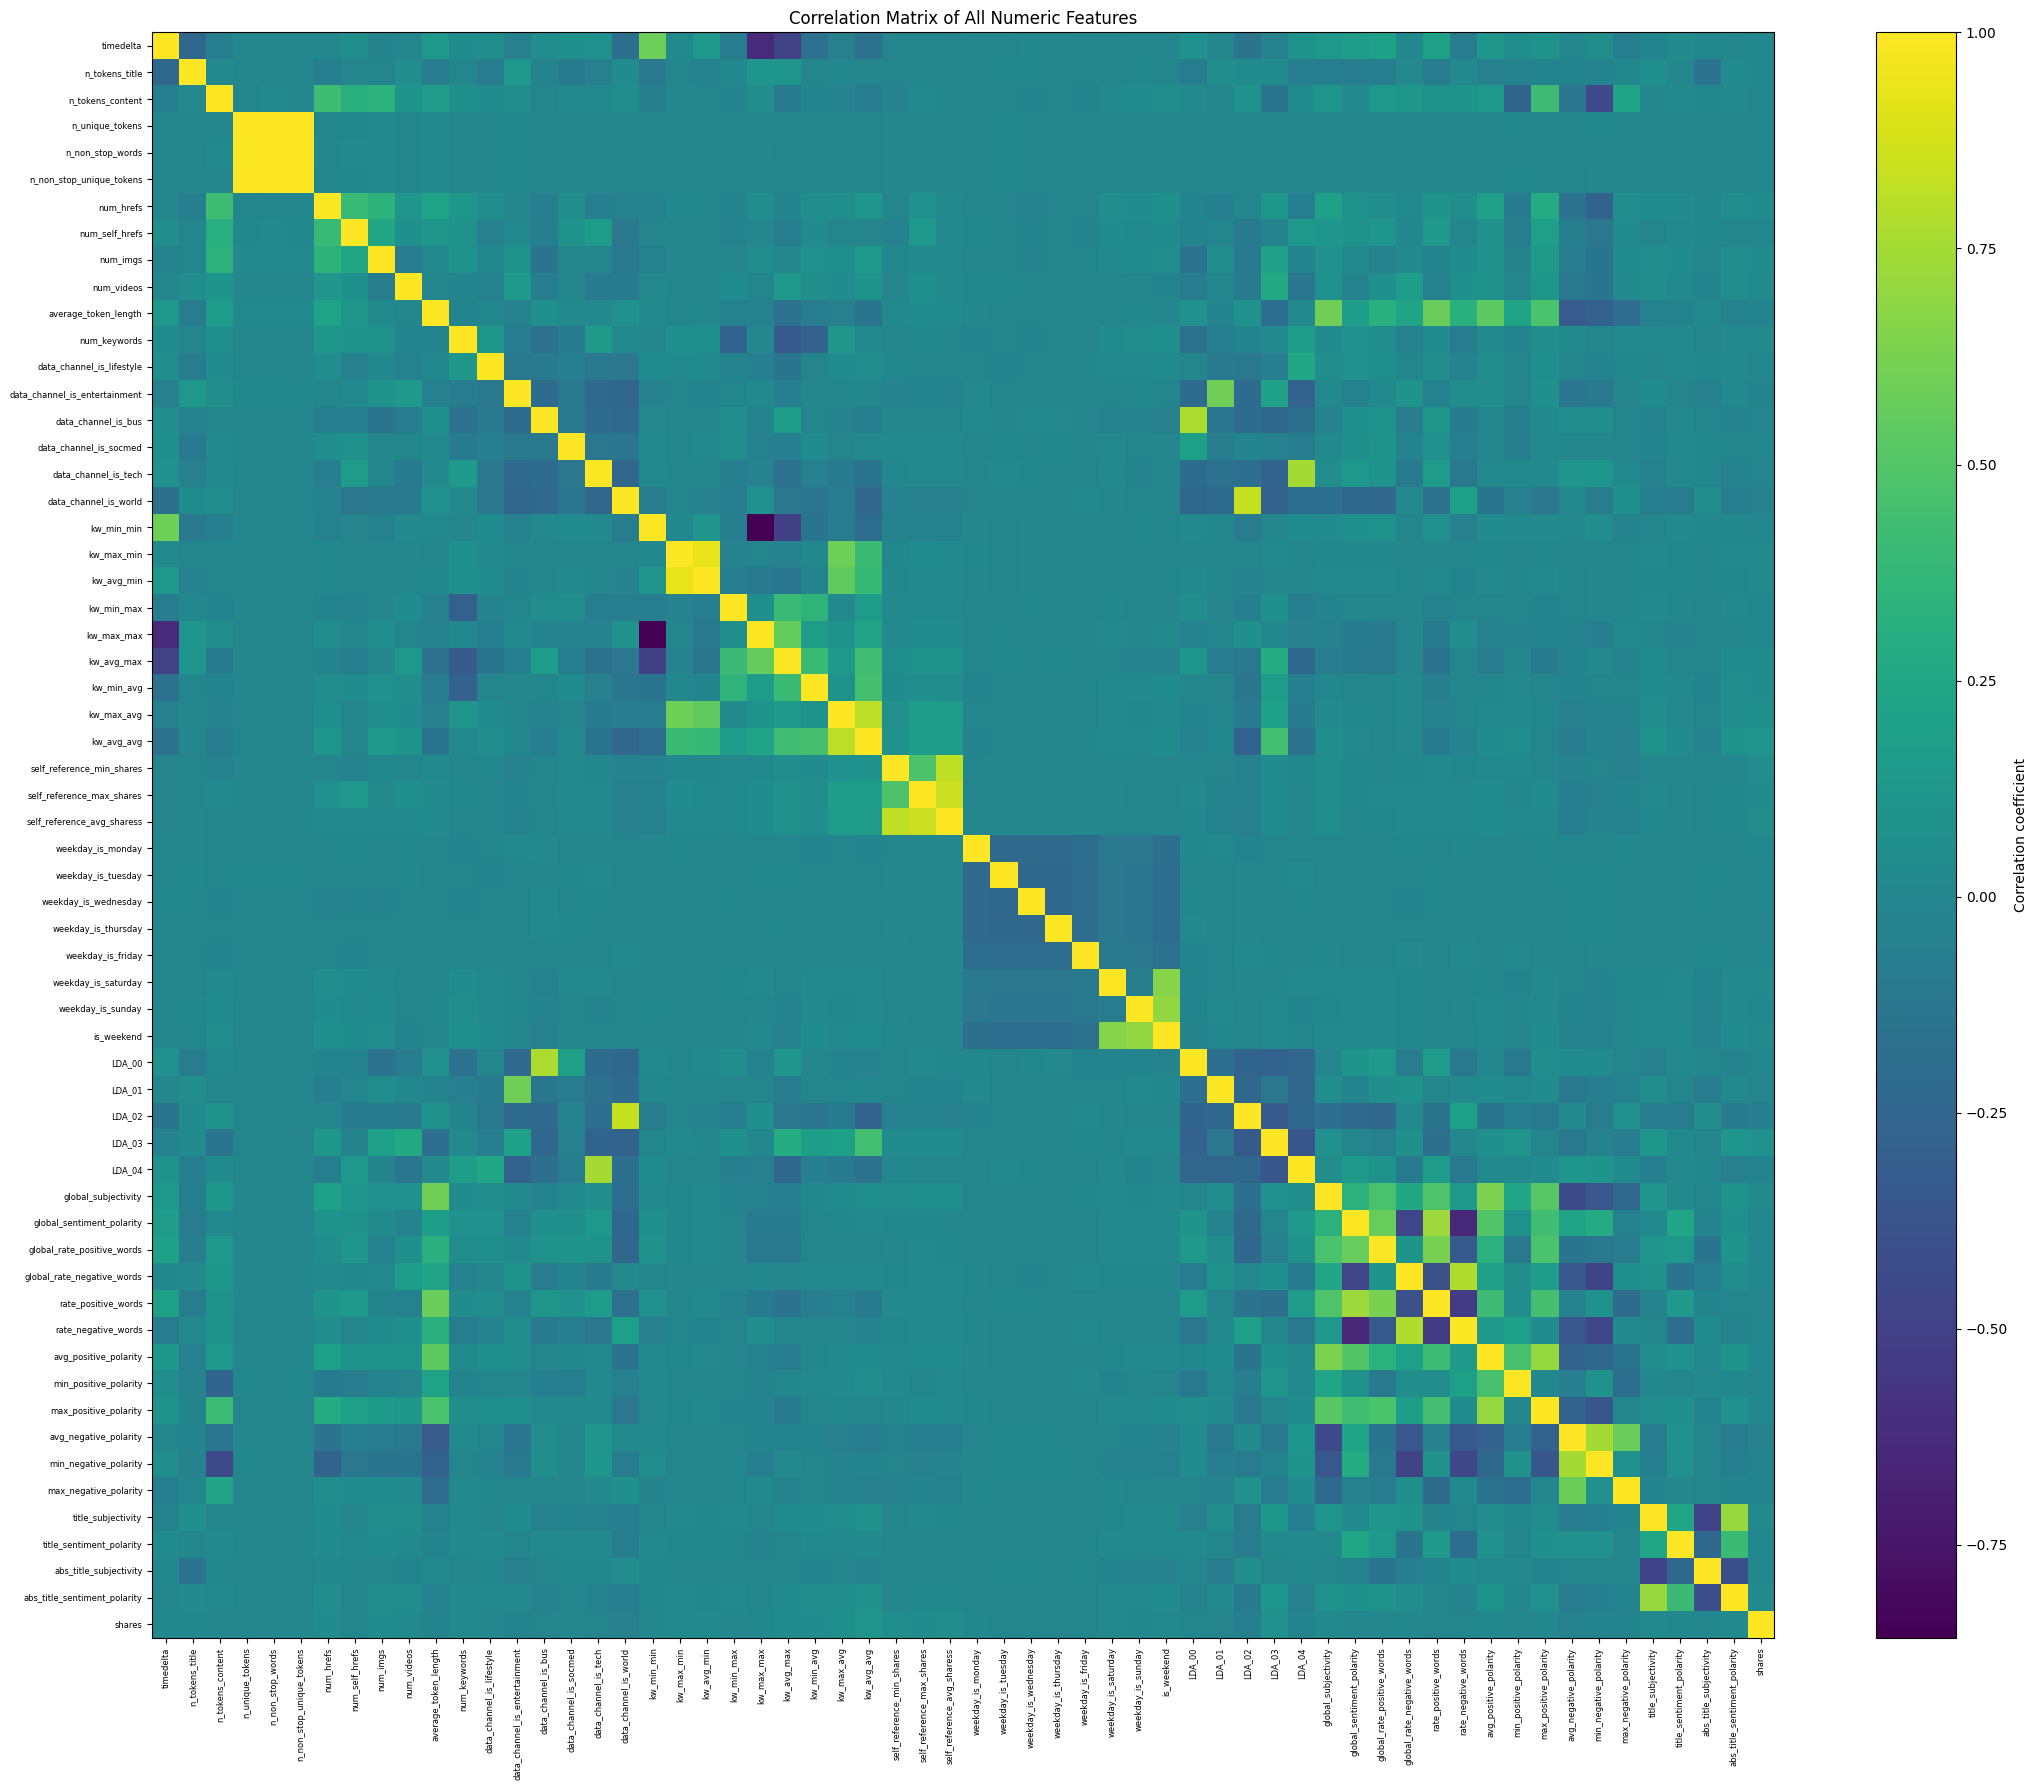

In [69]:
plt.figure(figsize=(22, 18))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=6)
plt.title("Correlation Matrix of All Numeric Features")
plt.tight_layout()
plt.show()

In [70]:
df["kw_worst_mean"] = df[["kw_min_min", "kw_max_min", "kw_avg_min"]].mean(axis=1)
df["kw_best_mean"]  = df[["kw_min_max", "kw_max_max", "kw_avg_max"]].mean(axis=1)
df["kw_avg_mean"]   = df[["kw_min_avg", "kw_max_avg", "kw_avg_avg"]].mean(axis=1)

df = df.drop(columns=[
    "kw_min_min", "kw_max_min", "kw_avg_min",
    "kw_min_max", "kw_max_max", "kw_avg_max",
    "kw_min_avg", "kw_max_avg", "kw_avg_avg"
])

In [71]:
df["self_reference_mean_shares"] = df[
    ["self_reference_min_shares",
     "self_reference_max_shares",
     "self_reference_avg_sharess"]
].mean(axis=1)

df = df.drop(columns=[
    "self_reference_min_shares",
    "self_reference_max_shares",
    "self_reference_avg_sharess"
])

In [72]:
df["content_sentiment_strength"] = (
    df["global_rate_positive_words"] +
    df["global_rate_negative_words"]
)

df = df.drop(columns=[
    "global_rate_positive_words",
    "global_rate_negative_words"
])

df["content_polarity_range"] = (
    df["max_positive_polarity"] - df["min_negative_polarity"]
)

df = df.drop(columns=[
    "max_positive_polarity",
    "min_negative_polarity"
])

In [73]:
n_rows, n_cols = df.shape
print(f"Dataset shape after aggregation: {n_rows} rows, {n_cols} columns")

Dataset shape after aggregation: 39644 rows, 51 columns


In [74]:
# Identify weekday dummy columns
weekday_cols = [c for c in df.columns if c.startswith("weekday_is_")]

# Create categorical weekday variable
df["weekday"] = (
    df[weekday_cols]
    .idxmax(axis=1)
    .str.replace("weekday_is_", "")
)

# Drop redundant columns
df = df.drop(columns=weekday_cols + ["is_weekend"])

In [75]:
print(df["weekday"].value_counts())
print("Number of columns after weekday removal:", df.shape[1])

weekday
wednesday    7435
tuesday      7390
thursday     7267
monday       6661
friday       5701
sunday       2737
saturday     2453
Name: count, dtype: int64
Number of columns after weekday removal: 44


In [76]:
channel_cols = [
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    "data_channel_is_world"
]

In [77]:
df["data_channel"] = (
    df[channel_cols]
    .idxmax(axis=1)
    .str.replace("data_channel_is_", "")
)

In [78]:
# Drop redundant columns
df = df.drop(columns=channel_cols)

In [79]:
df["data_channel"].value_counts()

data_channel
world            8427
lifestyle        8233
tech             7346
entertainment    7057
bus              6258
socmed           2323
Name: count, dtype: int64

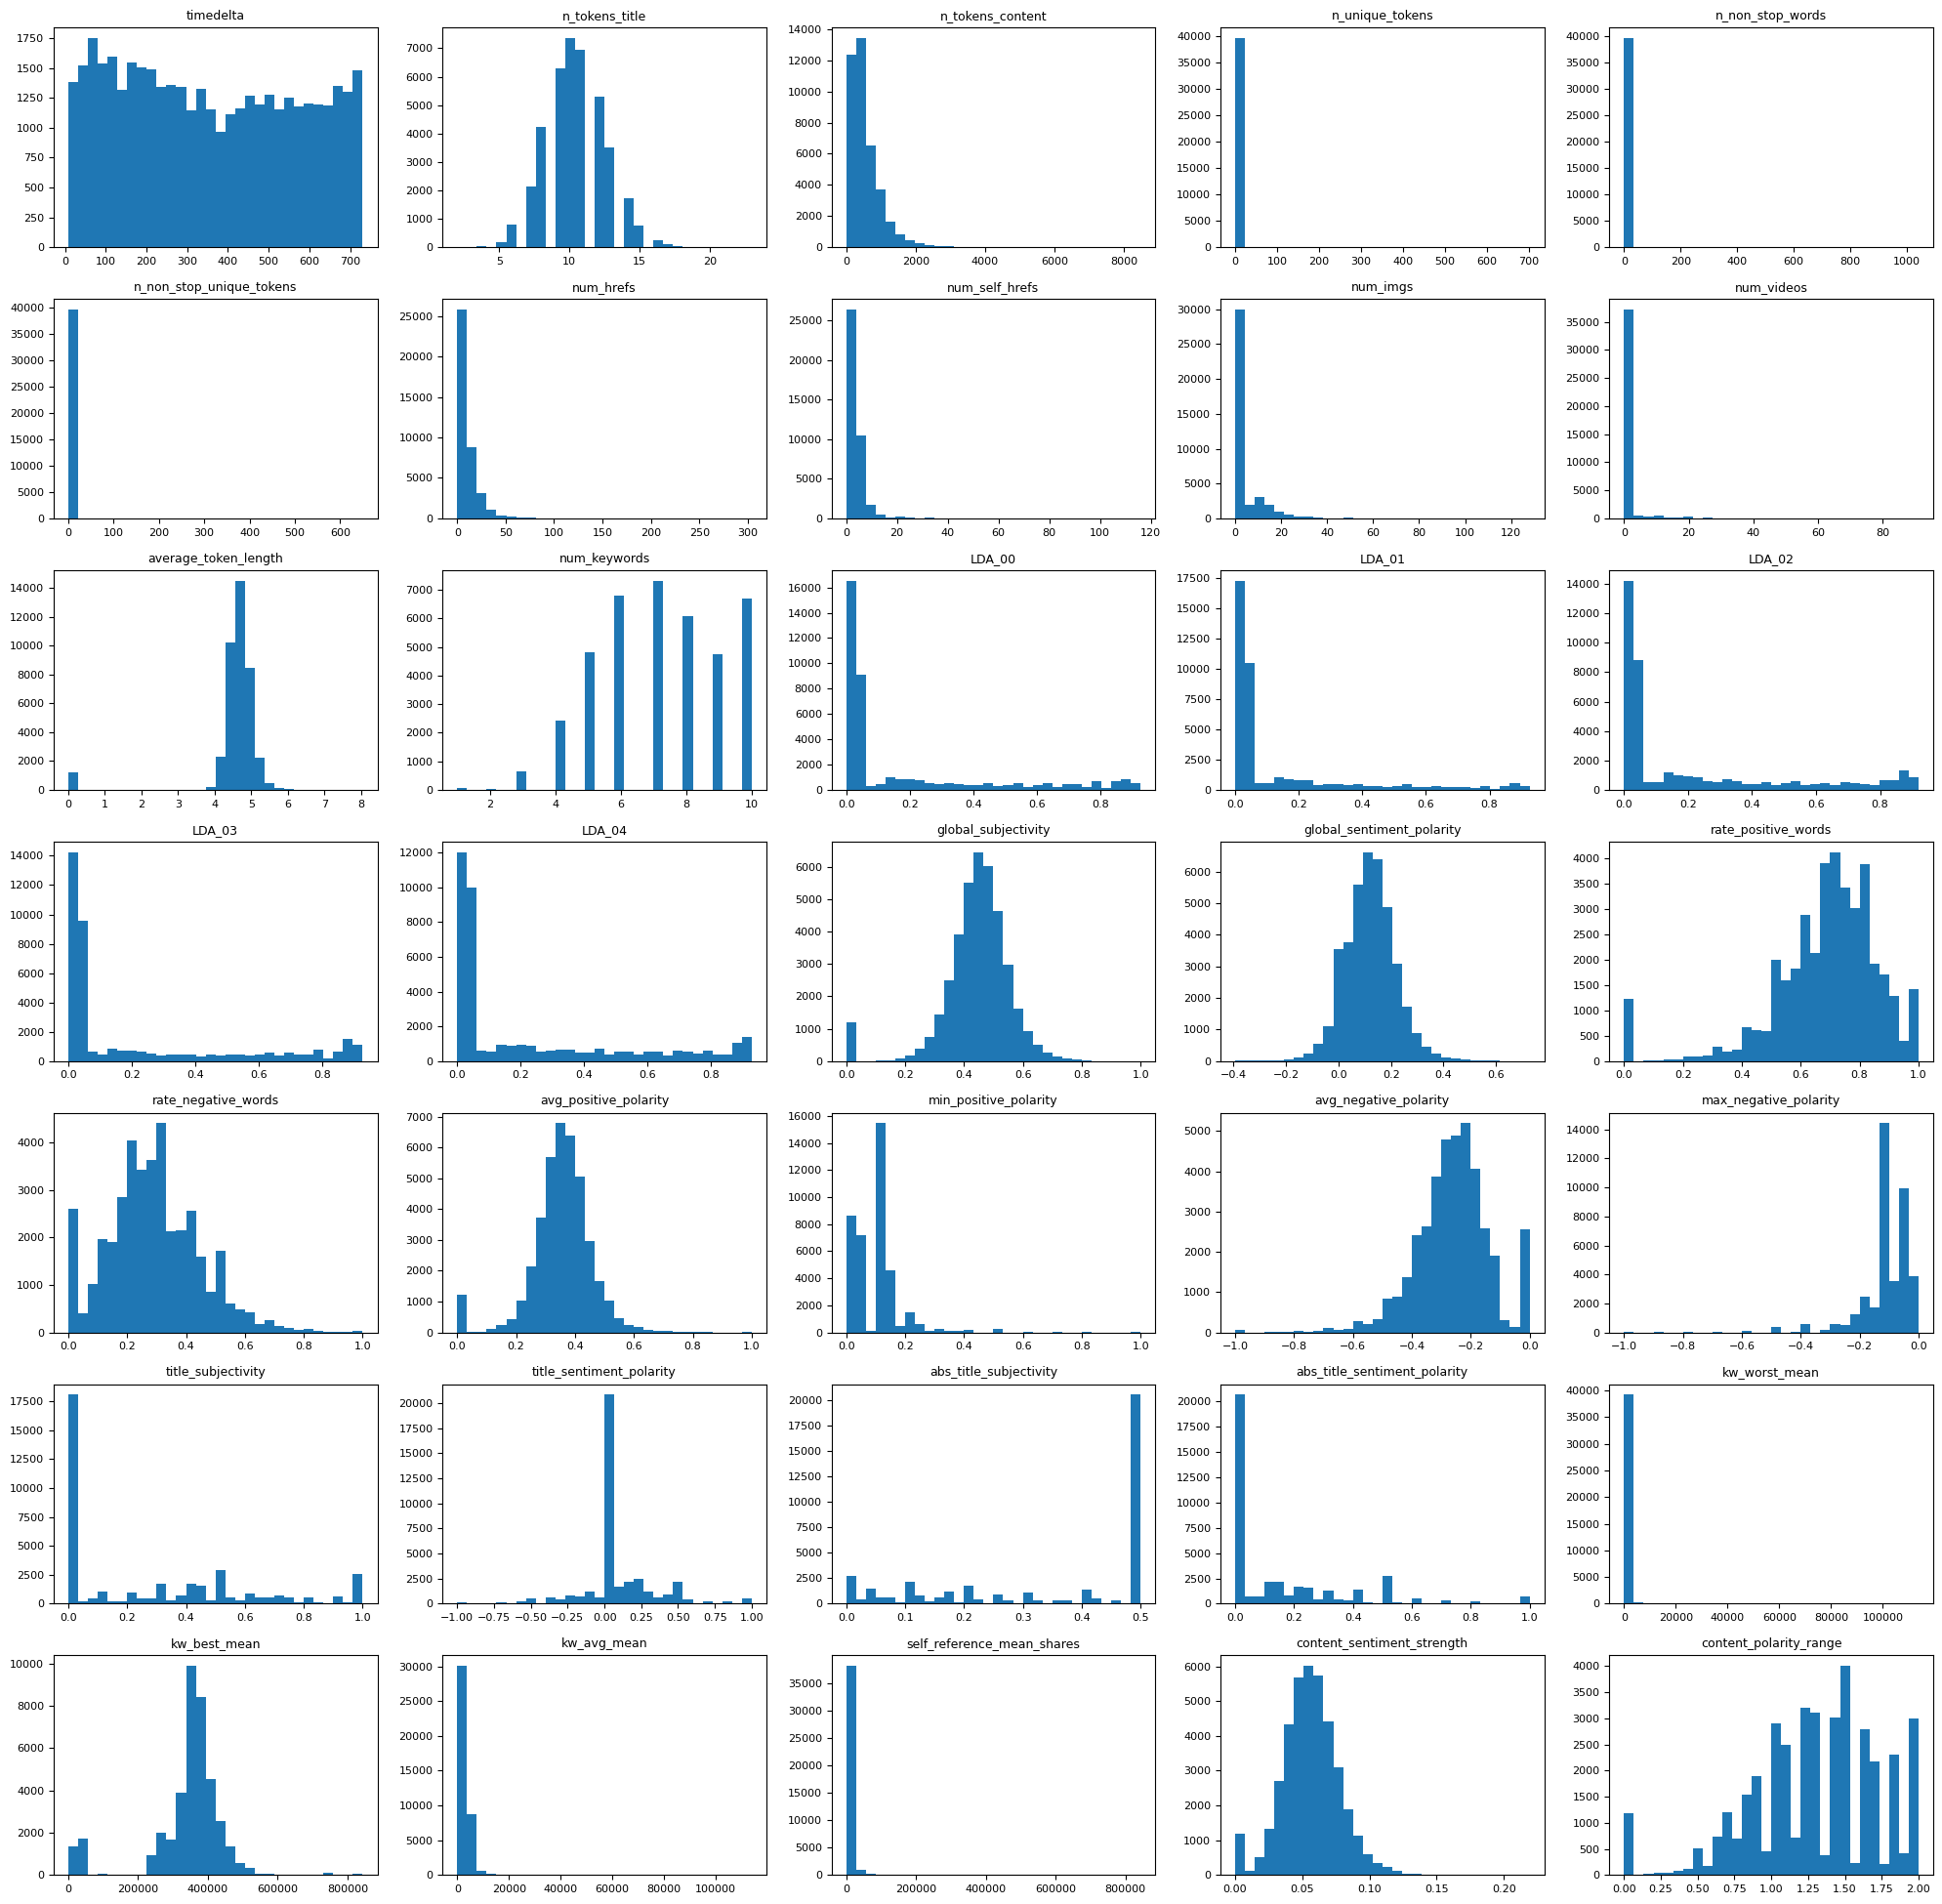

In [80]:
# Select numeric columns only, exclude target
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "shares"]  # predictors only

# Grid layout
n_cols = 5  
n_plots = len(numeric_cols)
n_rows = math.ceil(n_plots / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 2.8*n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

# Hide unused subplots (if any)
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

It is clearly visible that some of the variables are highly left or right-skewed, which makes them not really suitable ffor the further analysis. Because of that, we take all the skewed variables and transform the in to the logarithmized form, which should make the distributions closer to the normal ones.

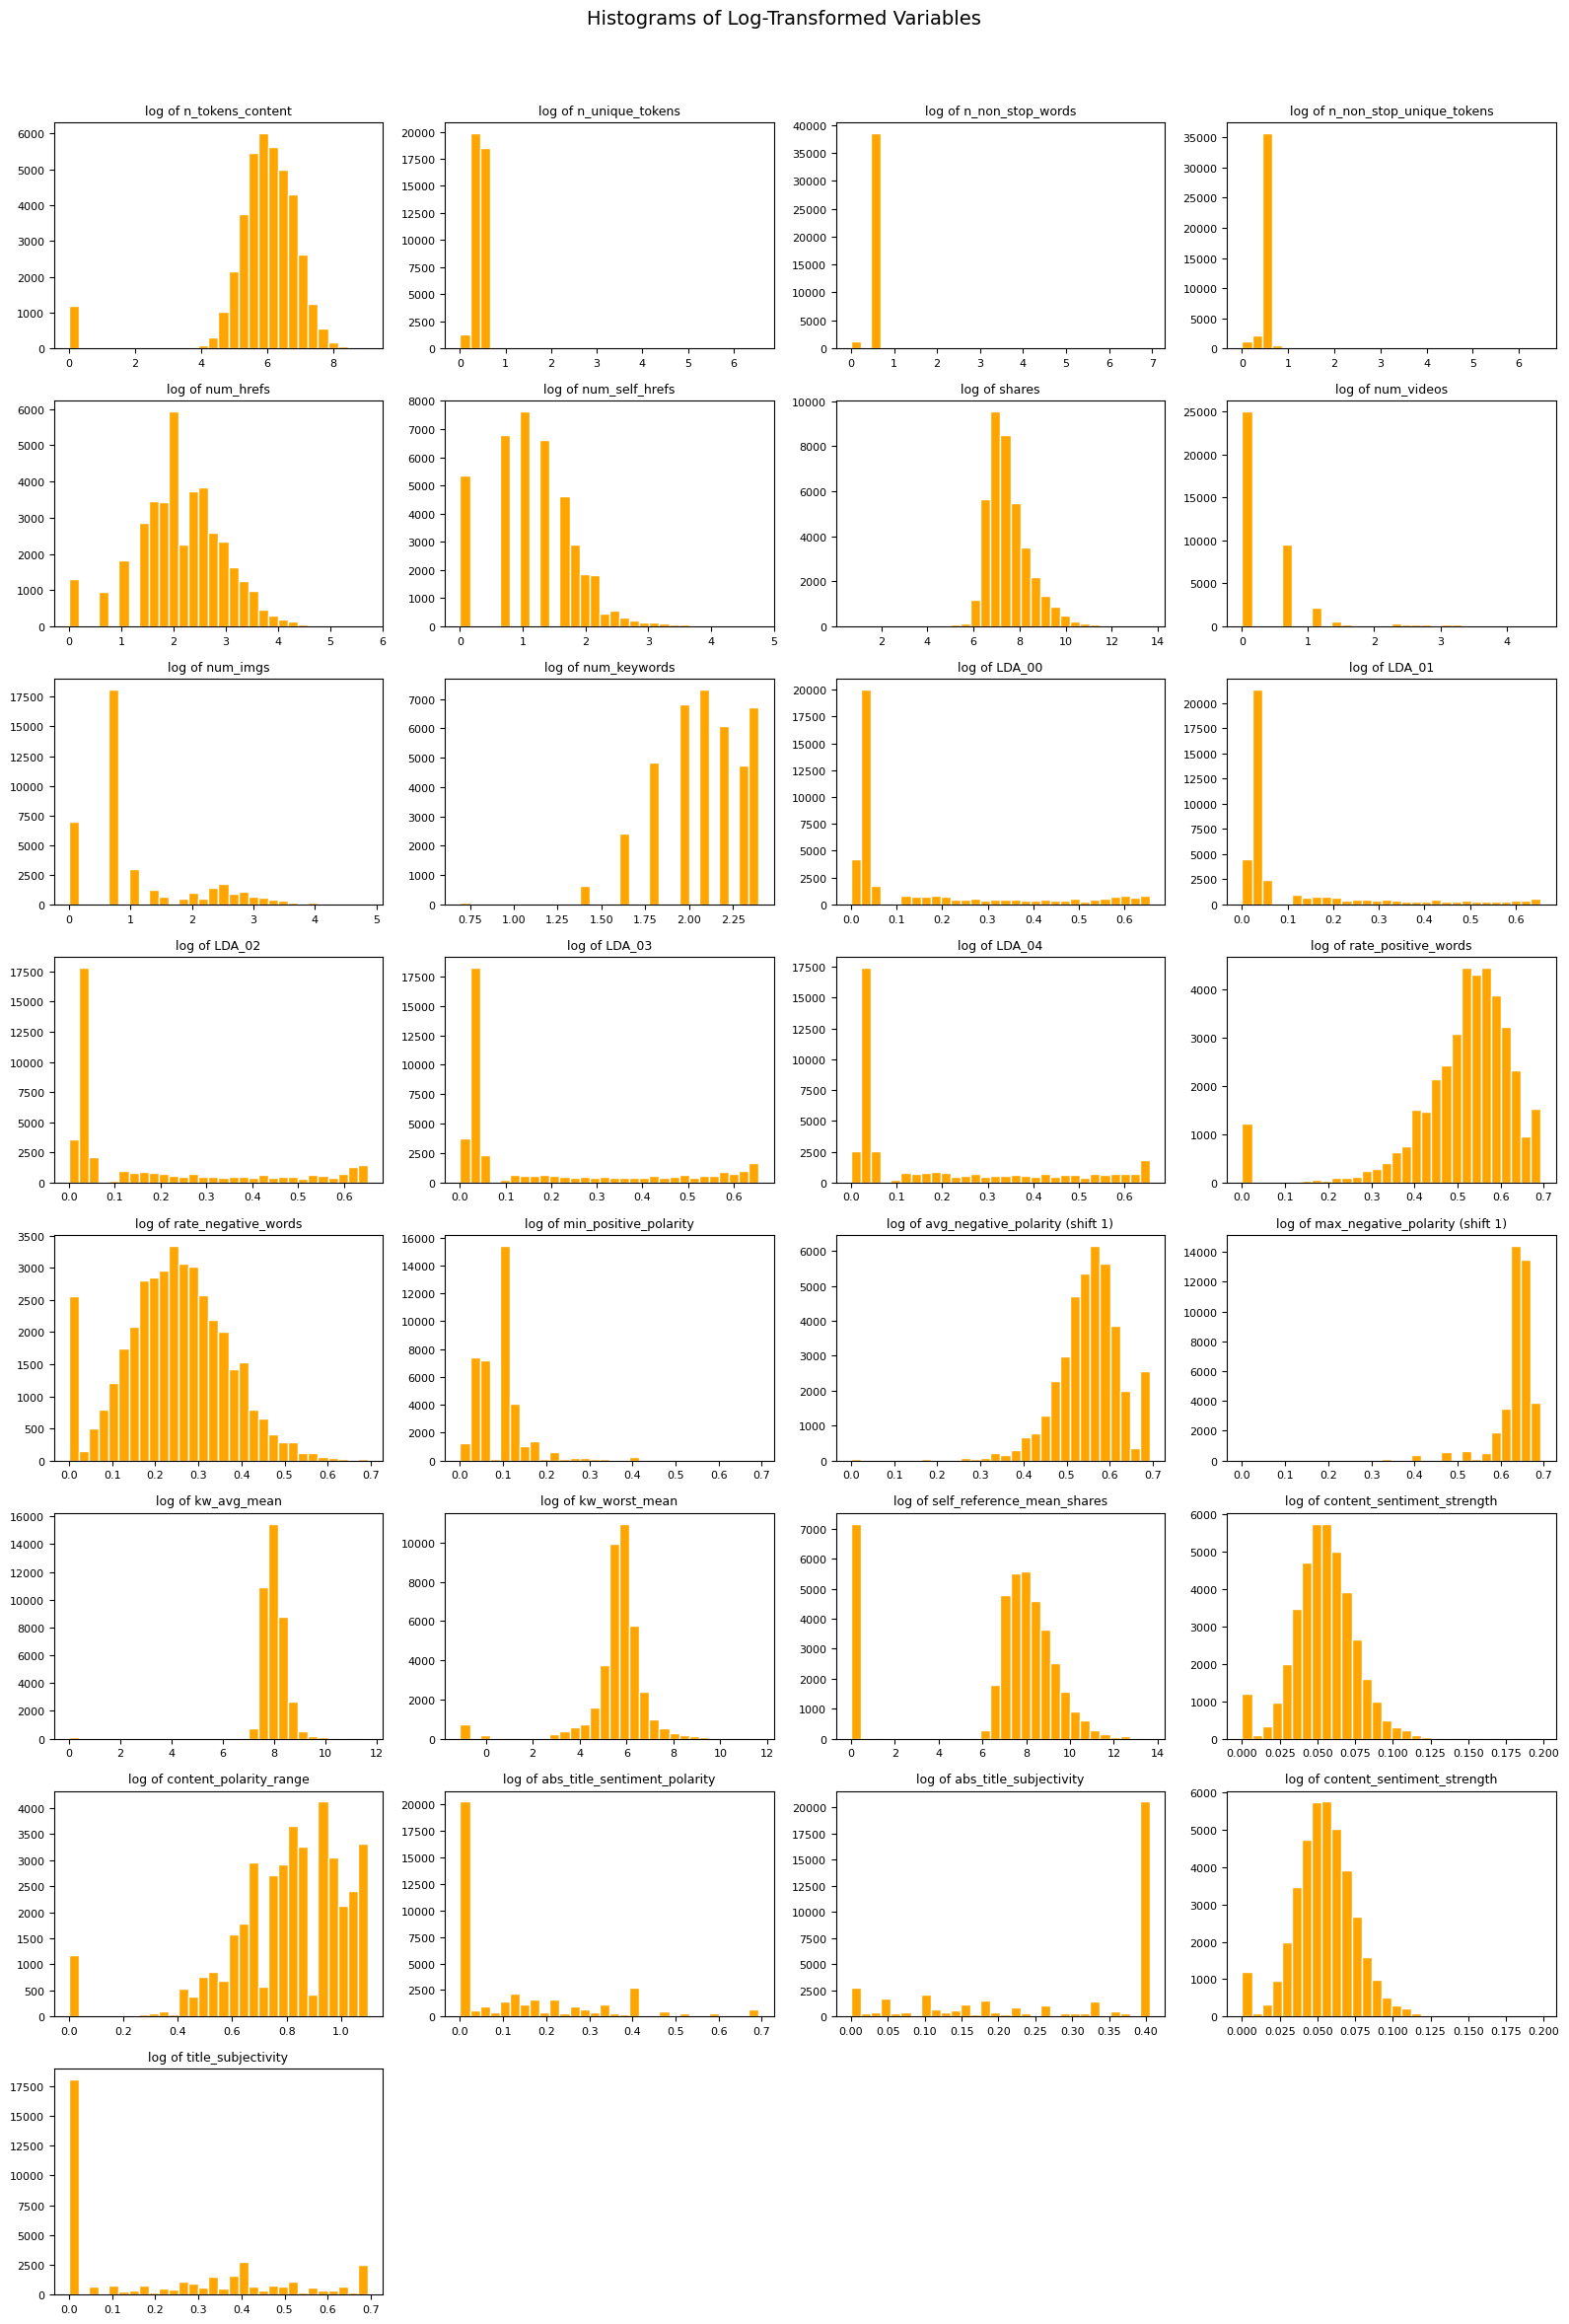

In [81]:
log_vars = [
    "n_tokens_content", "n_unique_tokens", "n_non_stop_words",
    "n_non_stop_unique_tokens", "num_hrefs", "num_self_hrefs",
    "shares", "num_videos", "num_imgs", "num_keywords",
    "LDA_00", "LDA_01", "LDA_02", "LDA_03", "LDA_04",
    "rate_positive_words", "rate_negative_words",
    "min_positive_polarity", "avg_negative_polarity", "max_negative_polarity",
    "kw_avg_mean", "kw_worst_mean","self_reference_mean_shares",
    "content_sentiment_strength", "content_polarity_range",
    "abs_title_sentiment_polarity", "abs_title_subjectivity",
    "content_sentiment_strength", "title_subjectivity"
]

log_vars = [c for c in log_vars if c in df.columns]

n_cols = 4
n_plots = len(log_vars)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(log_vars):
    raw = df[col].dropna()

    # Shift if needed so all values are > -1 for log1p
    min_val = raw.min()
    shift = (-min_val + 1e-6) if min_val <= -1 else 0.0

    data = np.log1p(raw + shift)

    axes[i].hist(data, bins=30, color="orange", edgecolor="white")
    if shift > 0:
        axes[i].set_title(f"log of {col} (shift {shift:.3g})", fontsize=9)
    else:
        axes[i].set_title(f"log of {col}", fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.suptitle("Histograms of Log-Transformed Variables", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


After this operation it's visible that some of the features are still not performing well in term of normal distribution. It is time to get rid of them.

In [83]:
# Drop specified (possibly already-removed) columns safely and report outcome
cols_to_drop = [
    "url",
    "timedelta",
    "n_unique_tokens",
    "n_non_stop_words",
    "n_non_stop_unique_tokens",
    "num_videos",
    "num_imgs",
    "num_self_hrefs",
    "LDA_00",
    "LDA_01",
    "LDA_02",
    "LDA_03",
    "LDA_04",
    "min_positive_polarity",
    "max_negative_polarity",
    "rate_negative_words",
    "content_polarity_range",
    "abs_title_sentiment_polarity",
    "abs_title_subjectivity",
    "title_subjectivity",
]



existing = [c for c in cols_to_drop if c in df.columns]
missing = [c for c in cols_to_drop if c not in df.columns]

if existing:
    df.drop(columns=existing, inplace=True, errors="ignore")

print(f"Dropped columns ({len(existing)}): {existing}")
if missing:
    print(f"Ignored (not present): {missing}")
print("New dataframe shape:", df.shape)

Dropped columns (1): ['num_imgs']
Ignored (not present): ['url', 'timedelta', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_videos', 'num_self_hrefs', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'min_positive_polarity', 'max_negative_polarity', 'rate_negative_words', 'content_polarity_range', 'abs_title_sentiment_polarity', 'abs_title_subjectivity', 'title_subjectivity']
New dataframe shape: (39644, 19)


At this point, our dataset contains 19 columns.

Knowing which columns are performing well after logarithmization, we change them also in the dataframe.

In [84]:
# Create log-transformed columns for specified features 
cols_to_log = [
    "n_tokens_content",
    "num_hrefs",
    "num_keywords",
    "rate_positive_words",
    "avg_negative_polarity",
    "kw_avg_mean",
    "kw_worst_mean",
    "self_reference_mean_shares",
    "content_sentiment_strength"
]

created = []
skipped = []

for col in cols_to_log:
    if col not in df.columns:
        skipped.append(col)
        continue

    # shift if necessary so values > -1 for log1p
    min_val = df[col].min()
    shift = (-min_val + 1e-6) if min_val <= -1 else 0.0

    new_col = f"log_{col}"
    df[new_col] = np.log1p(df[col] + shift)
    created.append((new_col, shift))

# Report
if created:
    print("Created log columns:")
    for new_col, shift in created:
        if shift:
            print(f" - {new_col} (shifted by {shift:.6g} before log1p)")
        else:
            print(f" - {new_col}")
if skipped:
    print("Skipped (not found):", skipped)

Created log columns:
 - log_n_tokens_content
 - log_num_hrefs
 - log_num_keywords
 - log_rate_positive_words
 - log_avg_negative_polarity (shifted by 1 before log1p)
 - log_kw_avg_mean
 - log_kw_worst_mean
 - log_self_reference_mean_shares
 - log_content_sentiment_strength


Here, we drop the columns, which logarithms we created.

In [85]:
# Drop specified columns safely
cols_to_drop = [
    "n_tokens_content",
    "num_hrefs",
    "num_keywords",
    "rate_positive_words",
    "avg_negative_polarity",
    "kw_avg_mean",
    "kw_worst_mean",
    "self_reference_mean_shares",
    "content_sentiment_strength"
]

existing = [c for c in cols_to_drop if c in df.columns]
missing = [c for c in cols_to_drop if c not in df.columns]

if existing:
    df.drop(columns=existing, inplace=True, errors="ignore")

print(f"Dropped ({len(existing)}): {existing}")
if missing:
    print(f"Not present (skipped): {missing}")
print("New dataframe shape:", df.shape)

# Update common helper lists in the notebook to avoid references to removed columns
for var in ["numeric_cols", "numeric_features", "other_numeric", "log_features", "log_feats", "predictors", "cols"]:
    if var in globals() and isinstance(globals()[var], list):
        globals()[var] = [x for x in globals()[var] if x not in cols_to_drop]


Dropped (9): ['n_tokens_content', 'num_hrefs', 'num_keywords', 'rate_positive_words', 'avg_negative_polarity', 'kw_avg_mean', 'kw_worst_mean', 'self_reference_mean_shares', 'content_sentiment_strength']
New dataframe shape: (39644, 19)


Let's do a quick check of the dataframe.

In [86]:
df

,n_tokens_title,average_token_length,global_subjectivity,global_sentiment_polarity,avg_positive_polarity,title_sentiment_polarity,shares,kw_best_mean,weekday,data_channel,log_n_tokens_content,log_num_hrefs,log_num_keywords,log_rate_positive_words,log_avg_negative_polarity,log_kw_avg_mean,log_kw_worst_mean,log_self_reference_mean_shares,log_content_sentiment_strength
0,12.0,4.680365,0.521617,0.092562,0.378636,-0.187500,593,0.000000,monday,entertainment,5.393628,1.609438,1.791759,0.570545,0.500776,0.000000,0.000000,6.208590,0.057666
1,9.0,4.913725,0.341246,0.148948,0.286915,0.000000,711,0.000000,monday,bus,5.545177,1.386294,1.609438,0.550046,0.631937,0.000000,0.000000,0.000000,0.057158
2,9.0,4.393365,0.702222,0.323333,0.495833,0.000000,1500,0.000000,monday,bus,5.356586,1.386294,1.945910,0.619039,0.427445,0.000000,0.000000,6.823286,0.064242
3,9.0,4.404896,0.429850,0.100705,0.385965,0.000000,1200,0.000000,monday,entertainment,6.276643,2.302585,2.079442,0.510826,0.488767,0.000000,0.000000,0.000000,0.060292
4,13.0,4.682836,0.513502,0.281003,0.411127,0.136364,505,0.000000,monday,tech,6.978214,2.995732,2.079442,0.620692,0.576506,0.000000,0.000000,8.789719,0.083195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,11.0,4.523121,0.482679,0.141964,0.333791,0.000000,1800,415054.166667,wednesday,tech,5.849325,2.302585,2.197225,0.543615,0.553886,8.066019,5.642055,10.378026,0.050715
39640,12.0,4.405488,0.564374,0.194249,0.374825,1.000000,1900,347595.238095,wednesday,socmed,5.796058,2.302585,2.079442,0.594707,0.581595,8.165183,5.588496,7.650169,0.047628
39641,10.0,5.076923,0.510296,0.024609,0.307273,0.136364,1900,381783.333333,wednesday,lifestyle,6.093570,3.218876,2.197225,0.455476,0.496866,8.362020,5.659773,7.244942,0.057158
39642,6.0,4.975073,0.358578,-0.008066,0.236851,0.000000,1100,365966.666667,wednesday,world,6.526495,2.397895,1.791759,0.382992,0.584869,7.451089,-1.098612,6.115892,0.043048


### Target Variable Analysis

As `shares` is our target varibale, let's now focus on it.

In [87]:
# Summary of target
display(df["shares"].describe())

count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64

- The target variable, `shares`, displays a **highly right-skewed distribution**.
- The **median** number of shares is **1400**, while the **mean** is substantially higher at **3395**, indicating the presence of extreme values.
- The **standard deviation** (**11,627**) is more than three times the mean, reflecting **very high variability** in article popularity.
- The **maximum observed value** reaches **843300 shares**, showing that a small number of articles achieve **viral popularity**, but they are perceived as outliers.
- In contrast, the majority of articles receive **relatively modest engagement**, with 75% of articles having fewer than **2800 shares**.

These characteristics motivate the use of a **logarithmic transformation of the target variable** in the modeling stage to reduce skewness and mitigate the influence of outliers.

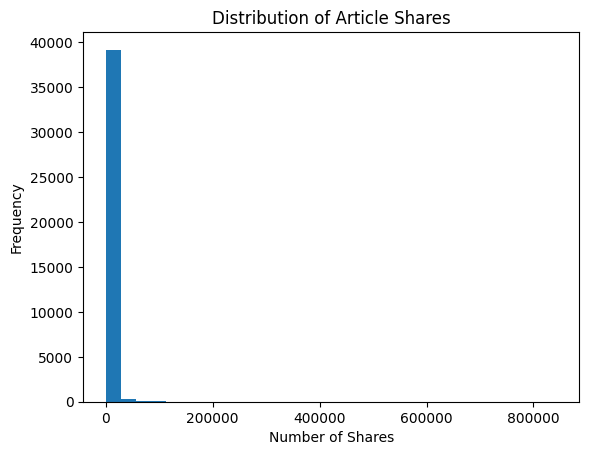

In [88]:
plt.figure()
plt.hist(df["shares"], bins=30)
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")
plt.title("Distribution of Article Shares")
plt.show()

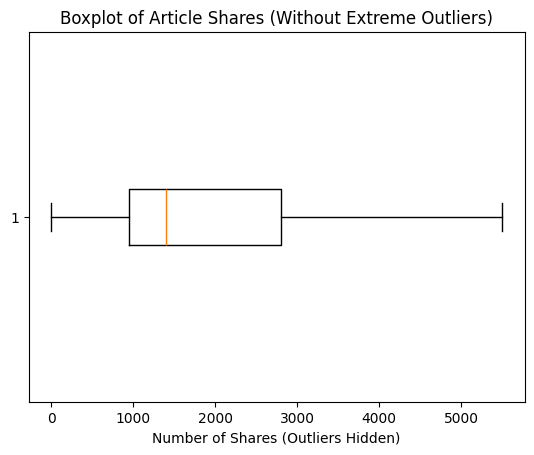

In [89]:
plt.figure()
plt.boxplot(df["shares"], vert=False, showfliers=False)
plt.xlabel("Number of Shares (Outliers Hidden)")
plt.title("Boxplot of Article Shares (Without Extreme Outliers)")
plt.show()

The boxplot (with extreme outliers removed) shows a strongly right‑skewed distribution of shares.

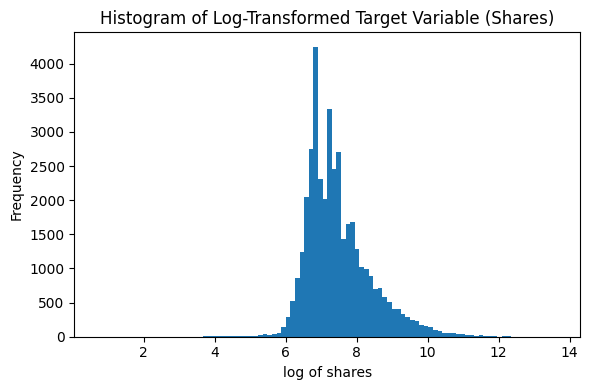

In [90]:
# Log-transform target for visualization
log_shares = np.log1p(df["shares"])

plt.figure(figsize=(6, 4))
plt.hist(log_shares, bins=100)
plt.xlabel("log of shares")
plt.ylabel("Frequency")
plt.title("Histogram of Log-Transformed Target Variable (Shares)")
plt.tight_layout()
plt.show()

After the logarithmization the target reflects definitely more the normal distribution than before.

Next, we create the logarithmized `shares` in the dataset, and subsequently we remove the non-logarithmized `shares` from the dataframe.

In [91]:
#create log-transformed target in the dataframe
df["log_shares"] = np.log1p(df["shares"])

In [92]:
# Drop the raw target column 'shares' from the dataframe

if "shares" in df.columns:
    df.drop(columns=["shares"], inplace=True)
    print("Dropped 'shares'. New shape:", df.shape)
else:
    print("'shares' column not present; no action taken.")

# Quick check of remaining columns
print("Columns now:", df.columns.tolist())

Dropped 'shares'. New shape: (39644, 19)
Columns now: ['n_tokens_title', 'average_token_length', 'global_subjectivity', 'global_sentiment_polarity', 'avg_positive_polarity', 'title_sentiment_polarity', 'kw_best_mean', 'weekday', 'data_channel', 'log_n_tokens_content', 'log_num_hrefs', 'log_num_keywords', 'log_rate_positive_words', 'log_avg_negative_polarity', 'log_kw_avg_mean', 'log_kw_worst_mean', 'log_self_reference_mean_shares', 'log_content_sentiment_strength', 'log_shares']


### Predictor vs Target Variable

We can also check how the target variable is related to some of the features, for example how shares are changing withing a week.

<Figure size 700x400 with 0 Axes>

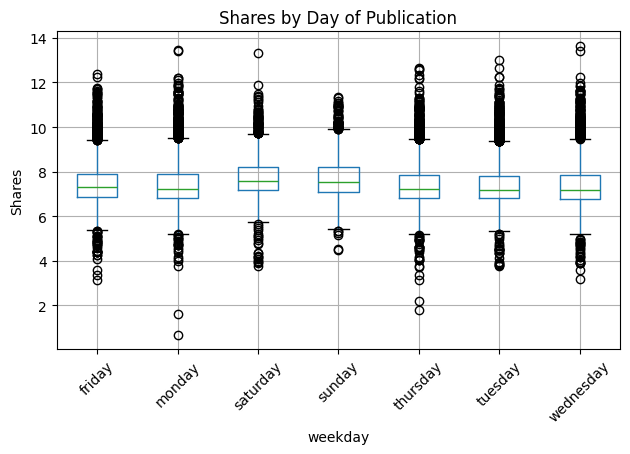

In [93]:
plt.figure(figsize=(7,4))
df.boxplot(column="log_shares", by="weekday")
plt.suptitle("")
plt.title("Shares by Day of Publication")
plt.ylabel("Shares")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The distributions across weekdays are very similar with comparable IQRs and lots of high outliers on every day. No weekday stands out as clearly better or worse, any differences are small compared to the overall variability.

The exploratory analysis showed that the dataset contains no missing values and includes a large number of heterogeneous predictors. The target variable, number of shares, exhibits a highly right-skewed distribution, which motivated a logarithmic transformation. Several count-based predictors were also strongly right-skewed and were selected for logarithmic transformation. Correlation analysis revealed substantial redundancy among groups of features, leading to feature aggregation and more compact representations. Overall, individual predictors show weak to moderate relationships with the target, suggesting that article popularity depends on complex, non-linear interactions.

Now, we can summarize all the variables on the colorfoul histograms:

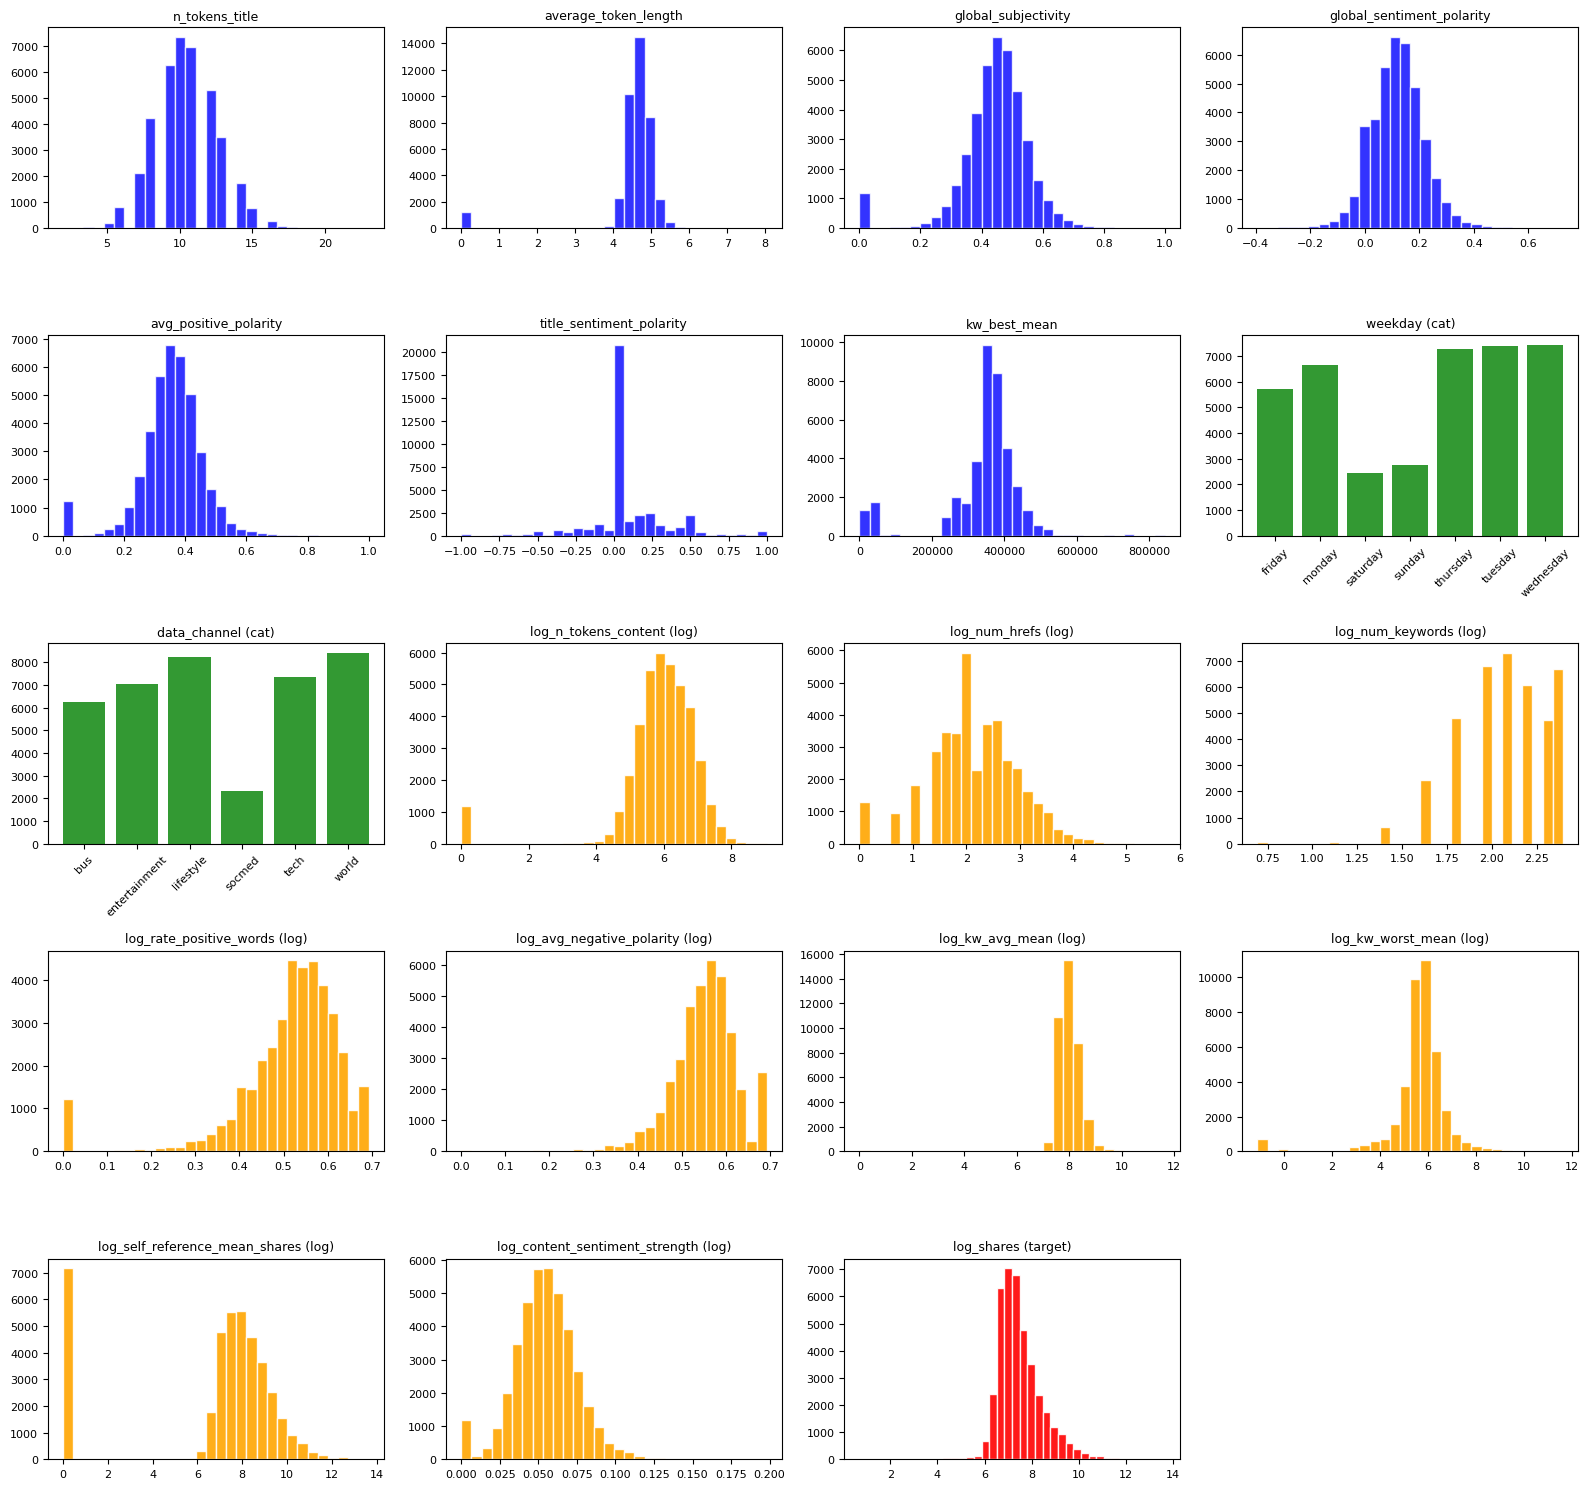

In [94]:
# Plot all features in a 4-column grid with color coding:
# - categorical: green
# - target 'log_shares': red
# - logarithmized features (start with 'log_'): orange
# - other numeric features: blue

cols = df.columns.tolist()
n_cols = 4
n_plots = len(cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

cat_color = "green"
target_color = "red"
log_color = "orange"
num_color = "blue"

for i, col in enumerate(cols):
    ax = axes[i]
    series = df[col].dropna()

    if col == "log_shares":
        # target (red)
        ax.hist(series, bins=40, color=target_color, edgecolor="white", alpha=0.9)
        ax.set_title(col + " (target)", fontsize=9)
    elif isinstance(df[col].dtype, np.dtype) and df[col].dtype == object:
        # categorical (green) -> bar plot of counts
        vc = series.value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=cat_color, alpha=0.8)
        ax.set_title(col + " (cat)", fontsize=9)
        ax.tick_params(axis="x", rotation=45)
    elif col.startswith("log_"):
        # log-transformed features (orange)
        ax.hist(series, bins=30, color=log_color, edgecolor="white", alpha=0.9)
        ax.set_title(col + " (log)", fontsize=9)
    else:
        # other numeric features (blue)
        ax.hist(series, bins=30, color=num_color, edgecolor="white", alpha=0.8)
        ax.set_title(col, fontsize=9)

    ax.tick_params(axis="both", labelsize=8)

# Hide any unused subplots
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [96]:
# Print current features in the dataframe 
all_columns = df.columns.tolist()

print("All columns (in df):")
for col in all_columns:
    print(f"- {col}")

df.shape

All columns (in df):
- n_tokens_title
- average_token_length
- global_subjectivity
- global_sentiment_polarity
- avg_positive_polarity
- title_sentiment_polarity
- kw_best_mean
- weekday
- data_channel
- log_n_tokens_content
- log_num_hrefs
- log_num_keywords
- log_rate_positive_words
- log_avg_negative_polarity
- log_kw_avg_mean
- log_kw_worst_mean
- log_self_reference_mean_shares
- log_content_sentiment_strength
- log_shares


(39644, 19)

Finally, we create a new correlation heatmap to check the correlations after the transformations. This time we will use different colour pallete.

,n_tokens_title,average_token_length,global_subjectivity,global_sentiment_polarity,avg_positive_polarity,title_sentiment_polarity,kw_best_mean,log_n_tokens_content,log_num_hrefs,log_num_keywords,log_rate_positive_words,log_avg_negative_polarity,log_kw_avg_mean,log_kw_worst_mean,log_self_reference_mean_shares,log_content_sentiment_strength,log_shares
n_tokens_title,1.000,-0.071,-0.057,-0.072,-0.050,0.000,0.129,-0.017,-0.064,-0.003,-0.065,-0.017,0.007,-0.068,0.047,-0.045,-0.019
average_token_length,-0.071,1.000,0.598,0.179,0.540,-0.017,-0.097,0.769,0.503,-0.022,0.652,-0.297,-0.097,0.016,0.311,0.388,-0.045
global_subjectivity,-0.057,0.598,1.000,0.339,0.632,0.034,-0.056,0.531,0.387,0.038,0.536,-0.426,0.045,0.058,0.277,0.513,0.075
global_sentiment_polarity,-0.072,0.179,0.339,1.000,0.497,0.238,-0.093,0.145,0.152,0.078,0.690,0.226,-0.003,0.075,0.063,0.228,0.049
avg_positive_polarity,-0.050,0.540,0.632,0.497,1.000,0.080,-0.059,0.485,0.355,0.030,0.458,-0.259,0.033,0.047,0.243,0.372,0.034
title_sentiment_polarity,0.000,-0.017,0.034,0.238,0.080,1.000,-0.022,0.003,0.031,0.029,0.131,0.085,0.034,0.030,-0.004,0.041,0.051
kw_best_mean,0.129,-0.097,-0.056,-0.093,-0.059,-0.022,1.000,-0.079,-0.014,-0.201,-0.129,-0.024,0.371,-0.280,0.139,-0.093,0.028
log_n_tokens_content,-0.017,0.769,0.531,0.145,0.485,0.003,-0.079,1.000,0.614,0.018,0.560,-0.302,-0.112,0.012,0.289,0.413,-0.023
log_num_hrefs,-0.064,0.503,0.387,0.152,0.355,0.031,-0.014,0.614,1.000,0.147,0.338,-0.231,0.056,0.066,0.244,0.203,0.079
log_num_keywords,-0.003,-0.022,0.038,0.078,0.030,0.029,-0.201,0.018,0.147,1.000,0.024,0.020,0.031,0.348,0.004,0.017,0.070


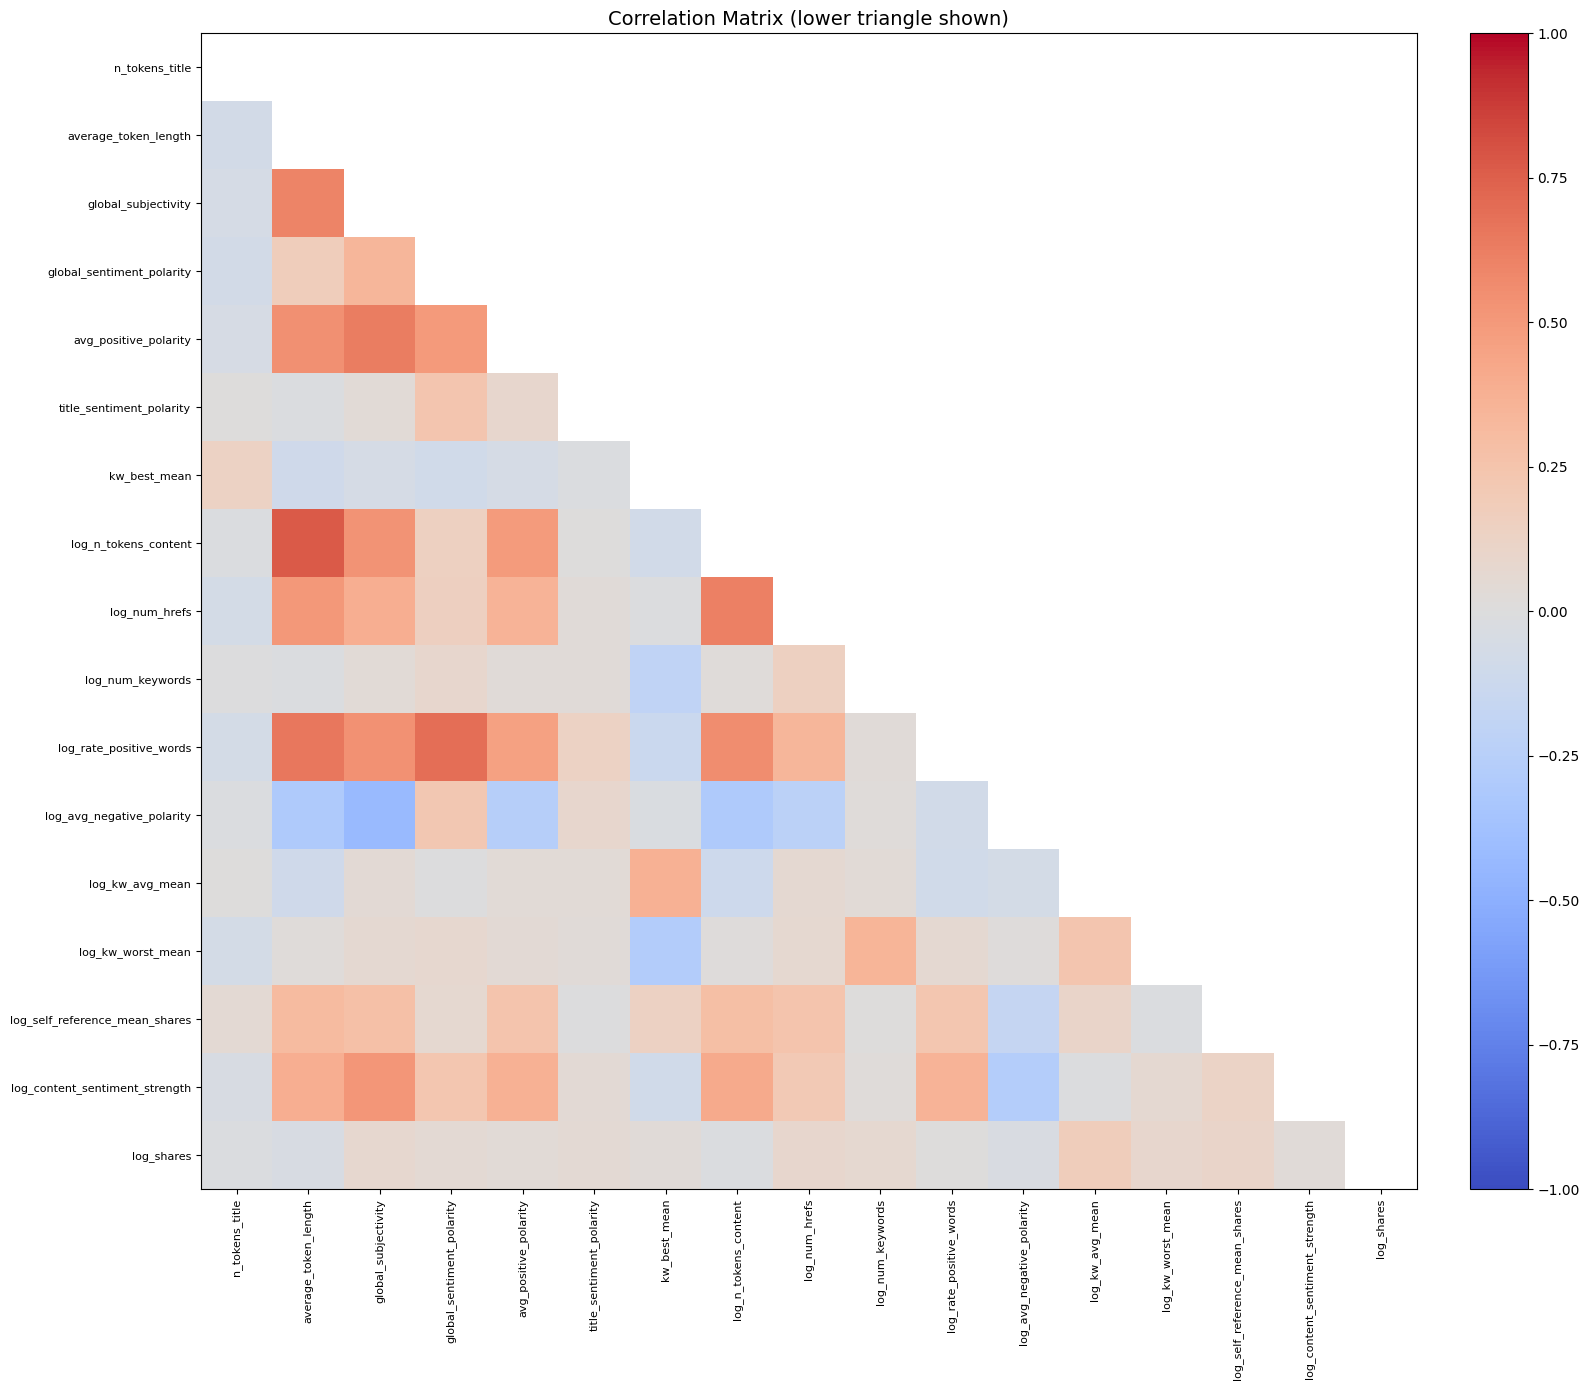

Top positive correlations with target (log_shares):


log_shares                        1.000000
log_kw_avg_mean                   0.179287
log_self_reference_mean_shares    0.105474
log_kw_worst_mean                 0.082800
log_num_hrefs                     0.079329
global_subjectivity               0.075174
log_num_keywords                  0.069696
title_sentiment_polarity          0.051038
global_sentiment_polarity         0.048927
avg_positive_polarity             0.034460
Name: log_shares, dtype: float64


Top negative correlations with target (log_shares):


average_token_length             -0.045321
log_avg_negative_polarity        -0.035714
log_n_tokens_content             -0.022876
n_tokens_title                   -0.019048
log_rate_positive_words           0.004188
kw_best_mean                      0.027715
log_content_sentiment_strength    0.029796
avg_positive_polarity             0.034460
global_sentiment_polarity         0.048927
title_sentiment_polarity          0.051038
Name: log_shares, dtype: float64

In [97]:
# Create and display correlation matrix for numeric features, plus a heatmap
corr_matrix = df.corr(numeric_only=True)

# Display the numeric correlation table 
display(corr_matrix.round(3))

# Heatmap 
mask = np.triu(np.ones_like(corr_matrix.values, dtype=bool))
masked_corr = np.ma.array(corr_matrix.values, mask=mask)

plt.figure(figsize=(16, 14))
cmap = plt.get_cmap("coolwarm")
im = plt.imshow(masked_corr, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index, fontsize=8)
plt.title("Correlation Matrix (lower triangle shown)", fontsize=14)
plt.tight_layout()
plt.show()

# Show correlations with the target (use log_shares if present)
target_col = "log_shares" if "log_shares" in corr_matrix.columns else "shares"
print(f"Top positive correlations with target ({target_col}):")
display(corr_matrix[target_col].sort_values(ascending=False).head(10))

print(f"\nTop negative correlations with target ({target_col}):")
display(corr_matrix[target_col].sort_values().head(10))

This heatmap is more readable, because of lower number of variables, and because of sharp colours. 

Two main clusters of correlated predictors are visible. The first cluster involves sentiment features such as global_subjectivity, global_sentiment_polarity, avg_positive_polarity and title_sentiment_polarity, which are positively correlated with one another. This reflects the fact that sentiment measures derived from the same textual content tend to move in the same direction. The second cluster involves keywords and article statistics, such as log_n_tokens_content, log_num_keywords, and kw_best_mean, which show moderate positive correlations, reflecting relationships between content length, keyword richness, and keyword performance.

Correlations with the target remain relatively weak for all features, although positive sentiment-related variables display slightly stronger correlations than the others. This supports the idea that more positive sentiment in content is modestly associated with higher engagement, but that no single feature provides a strong linear signal for predicting popularity. 

### Train-Test Split

After the logarithmic transformations are done, it is time to split the dataset. We do a regular 80-20 split.

In [98]:
#Train / test split using log_shares as target
X = df.drop(columns=["log_shares"])
y = df["log_shares"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (31715, 18)
X_test:  (7929, 18)
y_train: (31715,)
y_test:  (7929,)


### Encoding of categorical data

We have now 2 categorical variables and we decide that OneHoteEncoder will be the best one. We also considered the TargetEncoder, but for sure we can't use the encoder for ordinal variables. We use the pipeline for the purpose of encoding, in order to prevent the data leakage.

In [1975]:
# Encode categorical columns
categorical_features = [c for c in ["weekday", "data_channel"] if c in X_train.columns]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)


# 4. Modelling

We have our dataset split and prepared for the modelling. 

For the regression task, we experimented with a diverse set of machine learning algorithms to model nonlinear relationships and evaluate predictive performance.   
Random Forest is an ensemble of decision trees trained on bootstrapped samples, whose predictions are averaged to reduce variance. 

Gradient Boosting builds trees sequentially, with each new tree correcting the residual errors of the previous ones, improving accuracy over time. 

XGBoost is a highly optimized implementation of gradient boosting that incorporates regularization and efficient tree-building strategies to enhance performance and computational speed. 

ElasticNet is a linear model that combines L1 and L2 regularization to handle multicollinearity and perform variable selection. 

Finally, Support Vector Regression (SVR) maps data into higher-dimensional spaces using kernel functions and fits a margin-based regression line that is robust to outliers and nonlinear patterns.

## Gradient Boosting

In [1976]:
gbr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting RMSE: {rmse_gbr:.3f}")
print(f"Gradient Boosting R²: {r2_gbr:.3f}")


Gradient Boosting RMSE: 0.856
Gradient Boosting R²: 0.145


## Random Forest

In [ ]:
rf_model = Pipeline(steps=[
("preprocess", preprocess),
("model", RandomForestRegressor(
n_estimators=300,
random_state=42,
n_jobs=-1
))
])

# Fit model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.3f}")
print(f"Random Forest R²: {r2_rf:.3f}")


Random Forest RMSE: 0.857
Random Forest R²: 0.143


## Elastic Net

In [1978]:
en_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(
        alpha=0.1,        
        l1_ratio=0.5,     
        random_state=42,
        max_iter=10000   
    ))
])

# Fit model
en_model.fit(X_train, y_train)

# Predict on test set
y_pred_en = en_model.predict(X_test)

# Evaluation
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2_en = r2_score(y_test, y_pred_en)

print(f"Elastic Net RMSE: {rmse_en:.3f}")
print(f"Elastic Net R²: {r2_en:.3f}")

Elastic Net RMSE: 0.907
Elastic Net R²: 0.040


## Support Vector Regression

In [ ]:
# Baseline SVR model
svr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVR(
        kernel="rbf",      # radial basis function kernel (default)
        C=1.0,             # regularization strength
        epsilon=0.1      
    ))
])

# Fit model
svr_model.fit(X_train, y_train)

# Predict on test set
y_pred_svr = svr_model.predict(X_test)

# Evaluation
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR Baseline RMSE: {rmse_svr:.3f}")
print(f"SVR Baseline R²: {r2_svr:.3f}")

SVR Baseline RMSE: 0.877
SVR Baseline R²: 0.103


## XGBoost

In [ ]:
# XGBoost model with the SAME preprocessing
xgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=500,        # number of trees
        learning_rate=0.05,      # step size (
        max_depth=6,             # tree depth
        subsample=0.8,           # row sampling
        colsample_bytree=0.8,    # column sampling
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Fit model
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.3f}")
print(f"XGBoost R²: {r2_xgb:.3f}")

XGBoost RMSE: 0.858
XGBoost R²: 0.140


For each model, we used the same modelling pattern. 

We built a regression pipeline with our preprocess step (scaling/encoding) and a regressor. Later fit it on the training data and predicted on the test set. Finally, we computed the insightful metrics.

# 5. Hyperparameters Tuning

In the next step, we focus on tuning the parameters and finidng the best configuration for each model.

In [1981]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

We build a pipeline that preprocesses the data then trains a regressor.   
Later we train a hyperparameter search space and run RandomizedSearchCV optimizing RMSE and also tracking R². For thi purpose, we had to deifne the parameters to test.   
Then, the model fits the search on the training data and prints the best hyperparameters plus CV RMSE/R².   
Finally it uses the best model to predict the test set and prints test RMSE and R².   

## Random Forest

Desccription of tuning parameters:
- n_estimators: number of trees in the forest, more trees usually improve stability but increase time,
- max_depth: maximum depth of each tree, deeper trees fit more complex patterns but risk overfitting,
- min_samples_split: minimum samples required to split,
- min_samples_leaf: minimum samples required at a leaf, larger values smooth predictions and reduce variance,
- max_features: number of features considered at each split, smaller values add randomness and reduce overfitting,
- max_samples: fraction/number of samples used to train each tree.

In [1982]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 8, 12, 16, 20, 24],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__max_samples": [None, 0.7, 0.85, 0.95],
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)

best_idx = search.best_index_
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))



Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/Machine Learning 2/ML2_final_project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_samples': None, 'model__max_features': 'log2', 'model__max_depth': None}
Best CV RMSE: 0.8618504617665235
Best CV R²: 0.14215713510900482
Test RMSE: 0.8506153459386909
Test R²: 0.15592441767815213


In the next code snippet, we save the results to the variables, so later on we wll be able to compare the results.

In [1983]:
rf_search = search
y_pred_rf = y_pred

rf_cv_rmse = -rf_search.best_score_
rf_cv_r2 = rf_search.cv_results_["mean_test_r2"][rf_search.best_index_]

rf_test_rmse = rmse(y_test, y_pred_rf)
rf_test_r2 = r2_score(y_test, y_pred_rf)

### Gradient Boosting 

Description of tuning parameters (new ones):
- learning_rate: shrinks each tree’s contribution, lower values need more trees but can generalize better,
- subsample: fraction of training data used per tree.

In [1984]:
gbr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_dist = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

search = RandomizedSearchCV(
    gbr_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_gbr = search.best_estimator_
y_pred = best_gbr.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 4, 'model__learning_rate': 0.03}
Best CV RMSE: 0.8642358028747579
Best CV R²: 0.13740329352687014
Test RMSE: 0.8530029290152682
Test R²: 0.1511793141525516


In [1985]:
gbr_search = search
y_pred_enet = y_pred

enet_cv_rmse = -gbr_search.best_score_
enet_cv_r2 = gbr_search.cv_results_["mean_test_r2"][gbr_search.best_index_]

enet_test_rmse = rmse(y_test, y_pred_enet)
enet_test_r2 = r2_score(y_test, y_pred_enet)

### Elastic Net

Description of parameters:
- alpha: overall regularization strength. Higher values shrink coefficients more (simpler model), lower values allow more flexible fits,
- l1_ratio: mix between L1 (lasso) and L2 (ridge) penalties.

In [1986]:
enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", ElasticNet(random_state=42, max_iter=30000, tol=1e-4))
])

param_dist = {
    "model__alpha": np.logspace(-5, 1, 50),
    "model__l1_ratio": np.linspace(0.05, 1.0, 20),  # no 0
}

search = RandomizedSearchCV(
    enet_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_enet = search.best_estimator_
y_pred = best_enet.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__l1_ratio': np.float64(0.05), 'model__alpha': np.float64(0.0005179474679231213)}
Best CV RMSE: 0.8839019263688825
Best CV R²: 0.0976418373995889
Test RMSE: 0.8766727020146969
Test R²: 0.10341828573798806


In [1987]:
enet_search = search
y_pred_enet = y_pred

enet_cv_rmse = -enet_search.best_score_
enet_cv_r2 = enet_search.cv_results_["mean_test_r2"][enet_search.best_index_]

enet_test_rmse = rmse(y_test, y_pred_enet)
enet_test_r2 = r2_score(y_test, y_pred_enet)


### Support Vector Regression

Description of parameters:
- kernel: shape of the SVR model, rbf captures nonlinear patterns, poly fits polynomial relations, sigmoid is less common,
- C: regularization strength; higher C fits training data more closely, lower C gives smoother models,
- epsilon: larger epsilon ignores more small errors,
- gamma: larger values make the model more sensitive to single points,
- degree: polynomial degree.

In [1988]:
svr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVR())
])

param_dist = {
    "model__kernel": ["rbf", "poly", "sigmoid"],
    "model__C": np.logspace(-2, 2, 10),
    "model__epsilon": [0.01, 0.05, 0.1, 0.2, 0.5],
    "model__gamma": ["scale", "auto"],
    "model__degree": [2, 3, 4],  # only used for poly
}

search = RandomizedSearchCV(
    svr_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_svr = search.best_estimator_
y_pred = best_svr.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__epsilon': 0.5, 'model__degree': 4, 'model__C': np.float64(0.5994842503189409)}
Best CV RMSE: 0.8695194022562888
Best CV R²: 0.12682828178484312
Test RMSE: 0.8625657443228641
Test R²: 0.1320407749825152


In [1989]:
svr_search = search
y_pred_svr = y_pred

svr_cv_rmse = -svr_search.best_score_
svr_cv_r2 = svr_search.cv_results_["mean_test_r2"][svr_search.best_index_]

svr_test_rmse = rmse(y_test, y_pred_svr)
svr_test_r2 = r2_score(y_test, y_pred_svr)


### XGBoost

Description of parameters:
- n_estimators: number of trees; more trees can improve performance but take longer,
- learning_rate: shrinkage of each tree’s contribution,
- max_depth: maximum depth of each tree,
- subsample: fraction of rows used per tree,
- colsample_bytree: fraction of features used per tree,
- reg_alpha: L1 regularization strength, 
- reg_lambda: L2 regularization strength.

In [1990]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1],
    "model__reg_lambda": [1.0, 1.5, 2.0],
}

search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={"rmse": make_scorer(rmse, greater_is_better=False), "r2": "r2"},
    refit="rmse",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_idx = search.best_index_
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)
print("Best CV R²:", search.cv_results_["mean_test_r2"][best_idx])

best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_test)
print("Test RMSE:", rmse(y_test, y_pred))
print("Test R²:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/Weronika/Library/CloudStorage/OneDrive-Osobisty/Pulpit/Data-Science/Year 2 semester 3/Machine Learning 2/ML2_final_project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__subsample': 0.7, 'model__reg_lambda': 1.0, 'model__reg_alpha': 0.01, 'model__n_estimators': 600, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}
Best CV RMSE: 0.8599416572766044
Best CV R²: 0.1459494829688142
Test RMSE: 0.8501644937630375
Test R²: 0.1568189523513599


In [1991]:
xgb_search = search
y_pred_xgb = y_pred

xgb_cv_rmse = -xgb_search.best_score_
xgb_cv_r2 = xgb_search.cv_results_["mean_test_r2"][xgb_search.best_index_]

xgb_test_rmse = rmse(y_test, y_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_xgb)


# 6. Models comparison

Using the variables we created previously we compare the baseline models first:

In [1992]:
baseline_table = pd.DataFrame({
    "model": ["Random Forest", "Gradient Boosting", "Elastic Net", "XGBoost", "SVR"],
    "rmse": [rmse_rf, rmse_gbr, rmse_en, rmse_xgb, rmse_svr],
    "r2":   [r2_rf, r2_gbr, r2_en, r2_xgb, r2_svr],
}).set_index("model")

display(baseline_table.round(4))

,rmse,r2
model,,
Random Forest,0.8573,0.1426
Gradient Boosting,0.8559,0.1453
Elastic Net,0.9070,0.0403
XGBoost,0.8584,0.1405
SVR,0.8768,0.1032


- Overall performance is modest: R² values are low (≈0.04–0.15), so models explain only a small fraction of variance.
- Gradient Boosting is the best of the group (lowest RMSE 0.8559, highest R² 0.1453), but only slightly better than Random Forest and XGBoost.
- Elastic Net performs worst (highest RMSE 0.9070, lowest R² 0.0403).
- We clearly see that the results are extremly poor, we need to check how the situation changes after hyperparameters tuning.

In [1993]:
def cv_test_row(name, search_obj):
    best_idx = search_obj.best_index_
    cv_rmse = -search_obj.best_score_
    cv_r2 = search_obj.cv_results_.get("mean_test_r2", [np.nan])[best_idx]

    best_model = search_obj.best_estimator_
    y_pred = best_model.predict(X_test)

    return {
        "model": name,
        "cv_rmse": cv_rmse,
        "cv_r2": cv_r2,
        "test_rmse": rmse(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred),
    }

rows = []
rows.append(cv_test_row("Random Forest", rf_search))
rows.append(cv_test_row("Elastic Net", enet_search))
rows.append(cv_test_row("XGBoost", xgb_search))
rows.append(cv_test_row("SVR", svr_search))
rows.append(cv_test_row("Gradient Boosting", gbr_search))

cv_vs_test = pd.DataFrame(rows).set_index("model")
display(cv_vs_test.round(4))


,cv_rmse,cv_r2,test_rmse,test_r2
model,,,,
Random Forest,0.8619,0.1422,0.8506,0.1559
Elastic Net,0.8839,0.0976,0.8767,0.1034
XGBoost,0.8599,0.1459,0.8502,0.1568
SVR,0.8695,0.1268,0.8626,0.1320
Gradient Boosting,0.8642,0.1374,0.8530,0.1512


The table summarizes the performance of five regression models using both crossvalidation metrics and a test set. Two metrics are reported: Root Mean Squared Error (RMSE), where lower values indicate better performance, and R², where higher values indicate better explained variance.

Across all models, results are broadly consistent between cross-validation and test evaluation, indicating that the models generalize reasonably well without severe overfitting or underfitting. Among the evaluated models, XGBoost achieves the best overall performance, with the lowest test RMSE (0.8502) and the highest test R² (0.1568), closely followed by Random Forest and Gradient Boosting, which perform within a similar range. SVR also performs competitively, though with slightly higher error and lower variance explanation. Elastic Net yields the weakest performance, reflecting the limited predictive power of linear models for this dataset, which likely contains nonlinear relationships and interactions.


Summing up:

- CV and test metrics are close for all models, so there’s no strong overfitting, generalization looks stable.
- Best performers are the tree‑based models: XGBoost and Random Forest have the lowest test RMSE (~0.850) and highest test R² (~0.156).
- Gradient Boosting is close behind, SVR is middling, and Elastic Net is clearly weakest (lowest R², highest RMSE).
- Absolute R² values are still low (~0.10–0.16), so even the best models explain only a modest portion of variance.

Hyperparameters tuning didn't really help much in that case. Also investigating different models shows us, that it's not about the modelling, it's rather how insightful are the features selected.

We can also create graphs to see the predicted vs actual results.

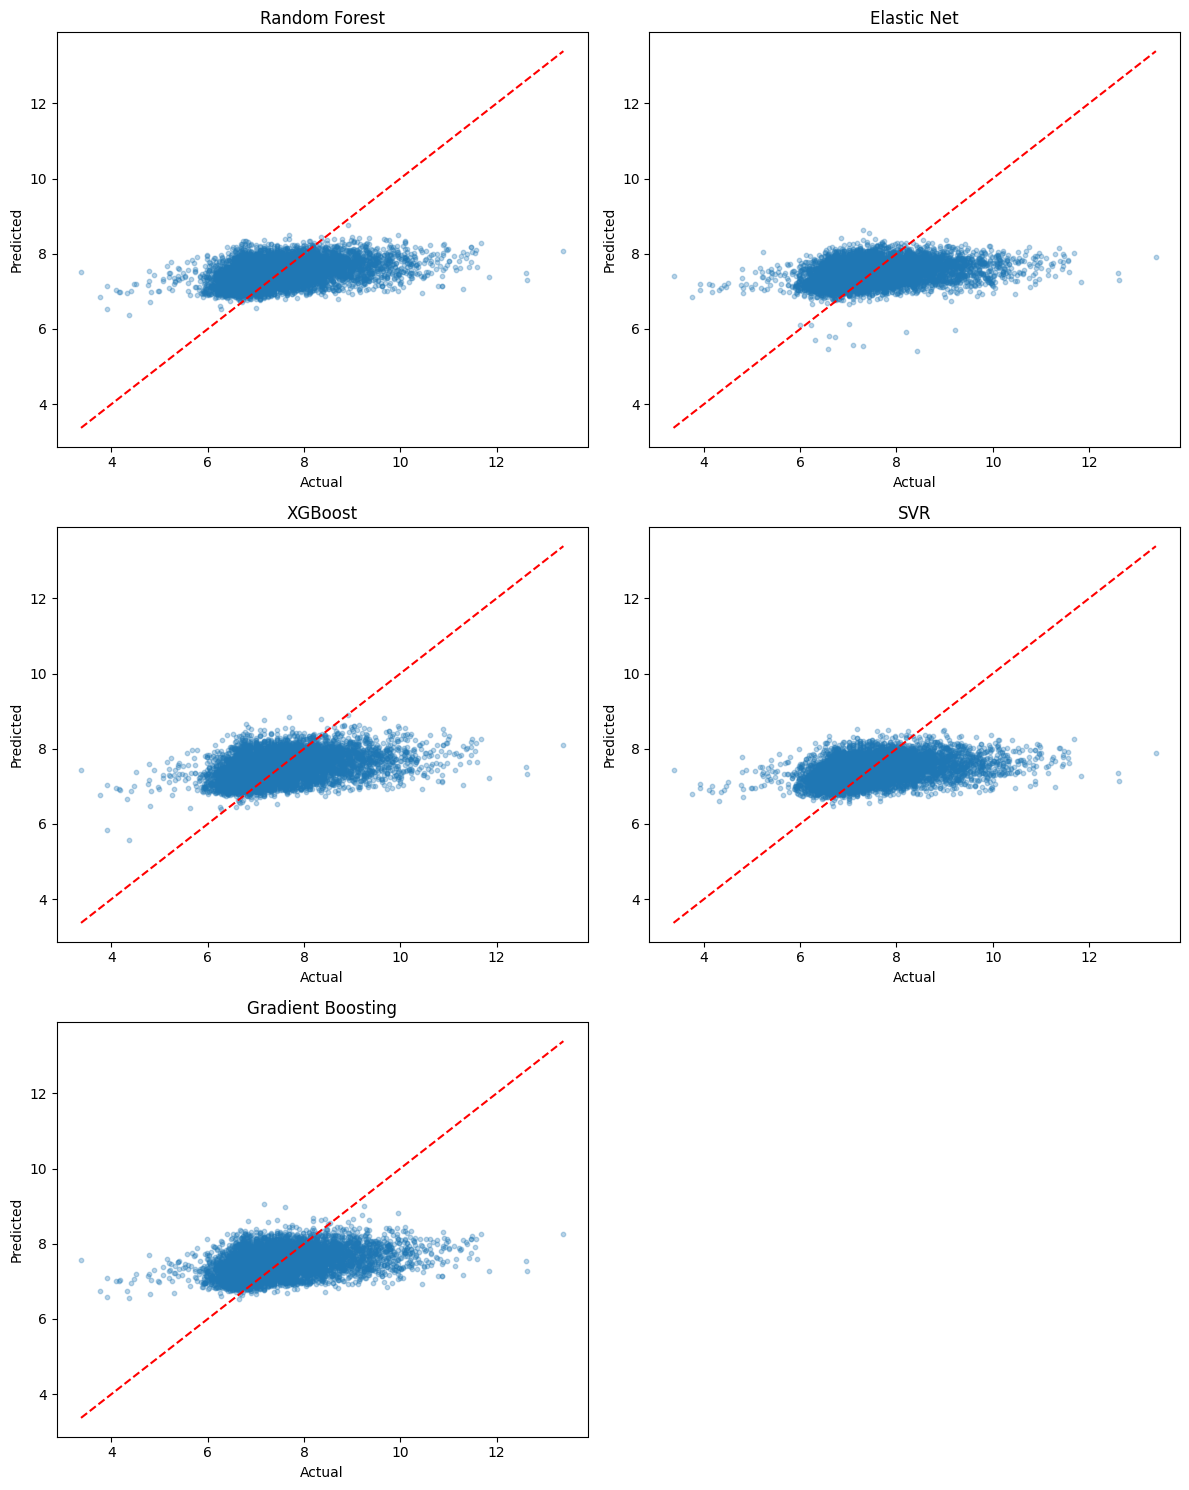

In [1995]:
tuned_models = [
    ("Random Forest", best_rf),
    ("Elastic Net", best_enet),
    ("XGBoost", best_xgb),
    ("SVR", best_svr),
    ("Gradient Boosting", best_gbr),
]

n_cols = 2
n_rows = int(np.ceil(len(tuned_models) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

y_min, y_max = y_test.min(), y_test.max()

for i, (name, model) in enumerate(tuned_models):
    y_pred = model.predict(X_test)
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    ax.plot([y_min, y_max], [y_min, y_max], color="red", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

for j in range(len(tuned_models), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


The graphs confirm, the models did not perform very well.

# 7. Conclusions and what next?

The results turned out to be very poor and not helpful at all. After seeing them, we decided on taking up some actions that we can do to improve the scores. We went through some articles and guides and took some inspiration. What we did:
- decided not to change the weekdays and data_channel variables into the categorical ones and then not encoding them - it didn't bring any meaningful change,
- decided on other choice of features - also didn't bring any meaningful change either,
- for the outliers, we already did the logarithmization, however it didn't help with all variables, some of them remained higly-skewed. We decided to apply additional technique of outliers removal - windsorization, but it didn't change the results at all, even after applying extremly narrow ranges,
- we also played with different parameters fo hyperparameters tuning, and with different numbers of iterations. Despite the longer computational time, the changes were neglegable (+/- 0.001 in both, RMSE and R2)

Out of curiosity, we checked what would be the baseline models results if we didn't do any of the feature engineering and what impact our actions actuallly had:
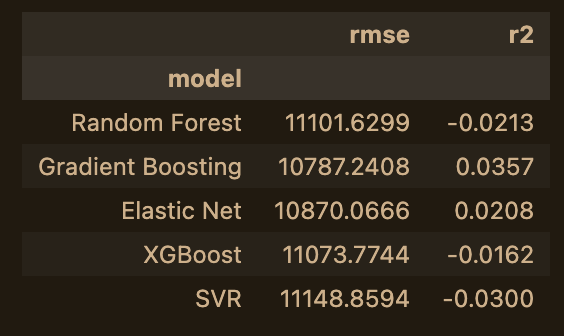

The results are saying that these are not real predictions, rather random guesses. But somehow it is a proof, that the actions we undertook did have impact on the dataset and played a role in the predictions, even though the results turned out not to be satisfactory.

Why this happend? The answer is probably because of the very weak correlation of features with target variable form the same beginning. It would be probably more benefitial, if the dataset contained some variables which would be more influental on shares themselves, for example related to some marketing strategies, external events (elections, scandals) or topic relevance to the news. 

Another reason might be highly-sked data in most features. Even applying skewness elimination techinques did not have a significant impact and some of the data remained impacted by outliers. 

We could also debate, whether the bigger sample would perform better. There are also some suggestions for poor performance, on some websites and forums that the data is inherently noisy, without specific patterns. However, we think that the biggest issue was the weak corrrelation problem.

What next? We think that this project has potential, and an idea for it is changing into the classification model - changing the numbers of shares into some ranges and inspecting the models then. We already have another classification project done and don't want to to quit with poor results, so we decided on an interesting move, which is repeating the actions, but changing the target variable. This will be presented in the second notebook.

# 8. Bibliography

1. "Machine Learning 1: classification methods" course materials by Michał Woźniak. University of Warsaw, Faculty of Economic Science.
2. "Machine Learning 2: predictive models, deep learning, neural network" course materials by Ewa Weychert. University of Warsaw, Faculty of Economic Science.
3. "Hands-on Machine Learning with Scikit-learn and TensorFlow" - Geron Aurelien 
4. "Machine Learning Engineering" - Andriy Burkov
5. Scikit-learn documentation [https://scikit-learn.org/stable/]
6. Log Transforming Target Variables and Enhancing Tree Ensembles [https://medium.com/@stevechesa/log-transforming-target-variables-and-enhancing-tree-ensembles-53be435d8041]
7. StatQuest with Josh Starmer [https://www.youtube.com/@statquest]
8. The When and How of Target Variable Transformations [https://arxiv.org/html/2504.20821v1]
9. Effect of transforming the targets in regression model [https://scikit-learn.org/stable/auto_examples/compose/plot_transformed_target.html]
10. Elastic Net Regression in R for Demography: End-to-End Case Studies [https://medium.com/analytics-mastery/elastic-net-regression-in-r-for-demography-end-to-end-case-studies-057df1eb8e86]
11. What is the best way to minimize the RMSE? [https://stackoverflow.com/questions/49905963/what-is-the-best-way-to-minimize-the-rmse]
12. Optimizing for RMSE vs. R2, for feature selection [https://www.reddit.com/r/datascience/comments/11g416x/optimizing_for_rmse_vs_r2_for_feature_selection/]
13. How to Improve Regression Model Performance: A Beginner’s Guide [https://medium.com/@softwarechasers/how-to-improve-regression-model-performance-a-beginners-guide-d35c20a1c462]
14. How to improve linear regression/model performance [https://www.reddit.com/r/datascience/comments/15cskh6/how_to_improve_linear_regressionmodel_performance/]
15. How can I improve my XGBoost model if hyperparameter tuning is having minimal impact? [https://stackoverflow.com/questions/60730157/how-can-i-improve-my-xgboost-model-if-hyperparameter-tuning-is-having-minimal-im]
16. Learn how to implement SVR for real-world data using Python, Sklearn, and hyperparameter tuning [https://medium.com/@jayedakhtar96/learn-how-to-implement-svr-for-real-world-data-using-python-sklearn-and-hyperparameter-tuning-7b12a2df9074]
17. Random Forest Regression — How it Helps in Predictive Analytics? [https://medium.com/@byanalytixlabs/random-forest-regression-how-it-helps-in-predictive-analytics-01c31897c1d4]
18. How to improve my regression models results more accurate in random forest regression [https://stackoverflow.com/questions/72355804/how-to-improve-my-regression-models-results-more-accurate-in-random-forest-regre]
19. Regression in machine learning [https://www.geeksforgeeks.org/machine-learning/regression-in-machine-learning/]
20. Top 15 Machine Learning Regression Algorithms [https://medium.com/@mehmetalitor/top-15-machine-learning-regression-algorithms-2cf128c8935e]
21. What do you do when your multiple regression analysis results are poor ? [https://www.researchgate.net/post/What_do_you_do_when_your_multiple_regression_analysis_results_are_poor]
22. Multiple Linear Regression: low R^2 value, but highly significant p-values (<0.01) [ https://www.reddit.com/r/AskStatistics/comments/1havonz/multiple_linear_regression_low_r2_value_but/]
23. Bad Linear regression results [ https://stats.stackexchange.com/questions/393706/bad-linear-regression-results]

